# 데이터 출처

- 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 소성가공 자원최적화 AI 데이터셋,
- KAIST(울산과학기술원, ㈜리쉐니에), 2022.12.23., www.kamp-ai.kr

# 1. Data Loading 및 기본 조회

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from datetime import datetime

# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.figure(figsize=(10, 8)) # 화면 크기 확대 (가로 10, 세로 8)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

<Figure size 1000x800 with 0 Axes>

In [94]:
org_df = pd.read_csv('./data/okm_augumented_2021.csv')

org_df.head(20)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5
5,20210101,5,89,83,99,98,92,0,-5.5,2.1,66,0.0,109.8,5,1,1,0.0,1.5
6,20210101,6,102,111,110,103,107,0,-5.6,1.5,67,0.0,109.8,5,1,1,0.0,1.5
7,20210101,7,92,75,48,29,61,0,-6.8,0.6,73,0.0,109.8,5,1,1,0.0,1.5
8,20210101,8,27,25,22,22,24,0,-5.6,0.0,72,0.0,109.8,5,1,1,0.0,1.5
9,20210101,9,22,22,22,22,22,0,-3.3,1.2,62,0.0,109.8,5,1,1,0.0,1.0


In [4]:

org_df.tail()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5


In [4]:
org_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


In [88]:
org_df[['m','전기요금(계절)']].groupby('m').value_counts()

m  전기요금(계절)
1  109.8       744
2  109.8       672
3  167.2       744
4  167.2       720
5  167.2       744
6  191.6       720
7  191.6       744
8  191.6       744
9  167.2       336
Name: count, dtype: int64

### 전기요금은 겨울 : 109.8원, 여름 : 191.6원, 봄/가을 : 167.2원 (kwh 당)

# 2. Data Cleansing & Review - 이상치 확인 및 데이터 확인

* Data 전처리 및 Cleansing을 위한 사본 저장

In [95]:
power_df = org_df.copy()

## 2.1 결측치 확인 및 정리

### 결측치 조사

In [7]:
org_df.isna().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

* 결측치 - 강수량 1건, 공장인원 17건

### 결측치 조치
* 0 으로 설정

In [96]:
power_df['강수량'] = org_df['강수량'].fillna(0)
power_df['공장인원'] = org_df['공장인원'].fillna(0)

power_df.isna().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          3
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

## 2.2 이상치 확인 및 정정

### 데이터 통계 요약 
* 평균, 분산, 표준편차, 1/4, 2/4, 3/4 분위
* 상관관계 : corr()

In [9]:
power_df.describe()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
count,6.168000e+03,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6165.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000
mean,2.021049e+07,12.428016,90.410182,92.695363,95.106355,95.037938,93.424125,467.344682,15.906064,2.063633,70.098735,2.243888,162.757198,4.003891,15.256809,4.770428,0.898851,1.313959
std,2.447756e+02,12.847309,55.349403,57.942122,59.285709,59.347554,57.355938,857.571815,9.160356,1.164118,22.996164,9.612754,30.820855,2.006957,8.799601,2.452431,1.983335,0.241700
min,2.021010e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,8.000000,0.000000,109.800000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2.021031e+07,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,0.000000,9.600000,1.200000,53.000000,0.000000,167.200000,2.000000,8.000000,3.000000,0.000000,1.000000
50%,2.021051e+07,12.000000,101.000000,104.000000,105.000000,107.000000,104.000000,45.000000,17.400000,1.900000,74.000000,0.000000,167.200000,4.000000,15.000000,5.000000,0.111111,1.500000
75%,2.021071e+07,18.000000,133.000000,143.000000,149.000000,149.000000,144.000000,637.250000,23.300000,2.800000,91.000000,0.100000,191.600000,6.000000,23.000000,7.000000,1.160310,1.500000
max,2.021091e+07,188.000000,207.000000,222.000000,218.000000,214.000000,208.000000,9830.000000,33.400000,7.600000,98.000000,122.400000,191.600000,7.000000,31.000000,9.000000,48.386364,1.500000


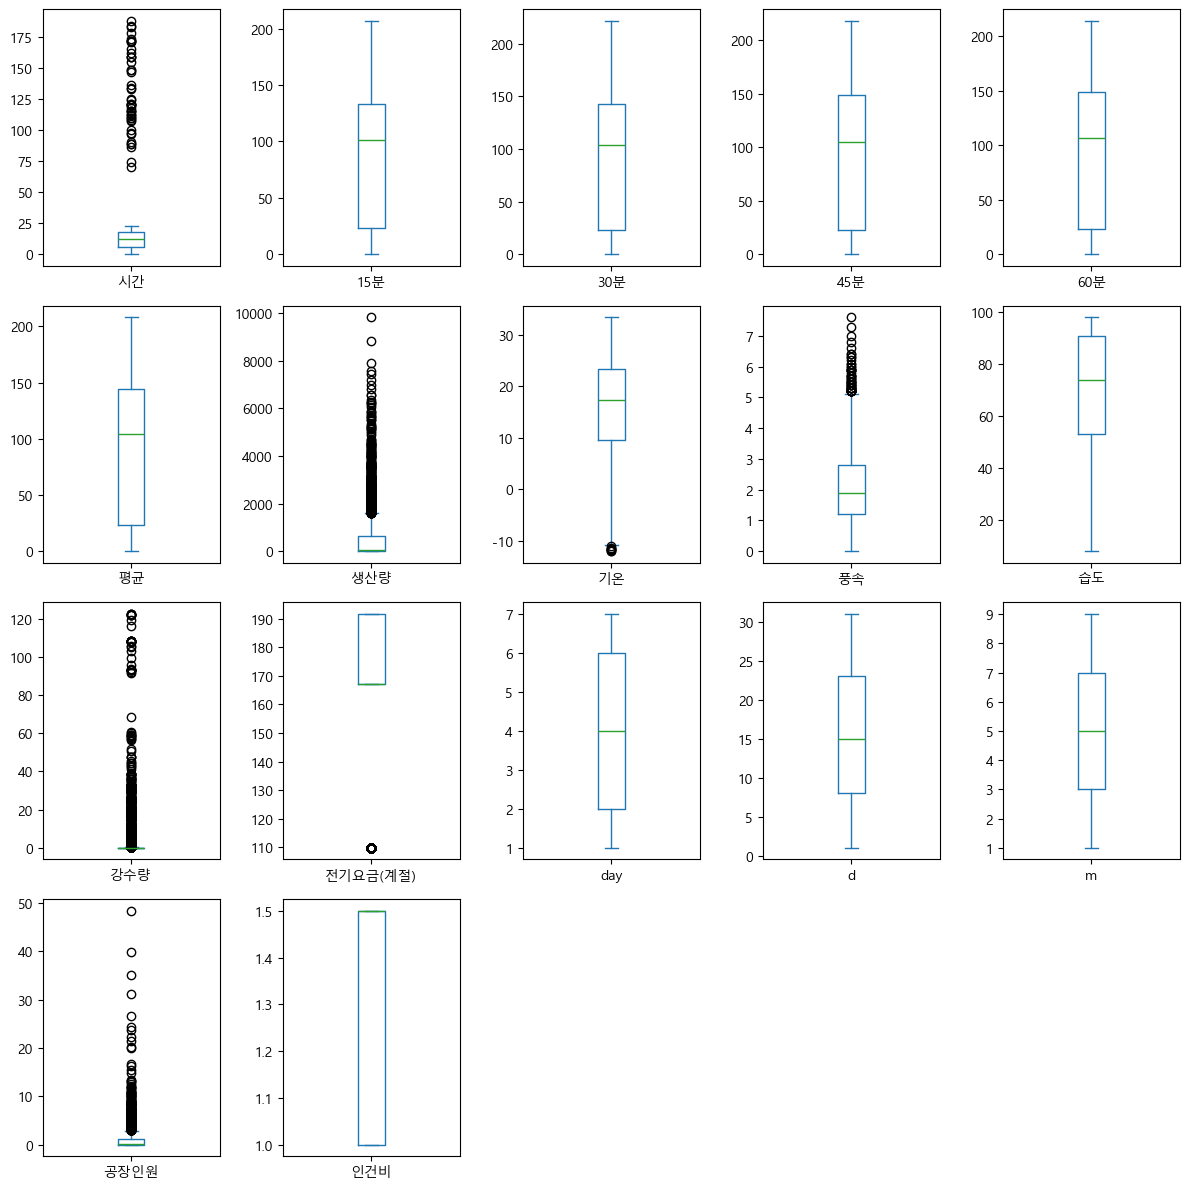

In [10]:
# 일자는 제외
# sns.boxplot(data=power_df.drop(columns=['날짜', '생산량']))
# plt.title('Seaborn Boxplot')

# 한 줄에 5개씩 배치 (열 개수에 맞춰 행 수는 자동 계산)
df = power_df.drop(columns=['날짜'])
df.plot(kind='box', subplots=True, layout=(-1, 5), figsize=(12, 12))
plt.tight_layout()
plt.show()

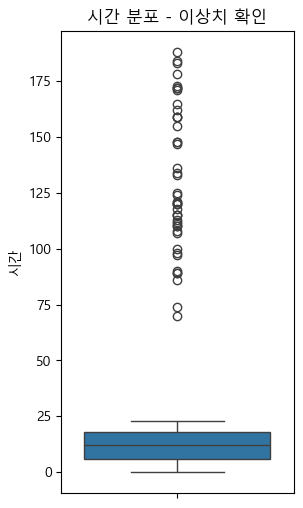

In [11]:
plt.figure(figsize=(3, 6))
sns.boxplot(data=power_df['시간'])
plt.title('시간 분포 - 이상치 확인')
plt.show()

### 시간 정보가 잘못됨

In [97]:
power_df['시간'].unique(), len(power_df['시간'].unique())

# print(len(power_df['시간'].unique()))

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  70,  89,
         90,  97, 107, 108, 112, 113, 115, 118, 120, 121, 124, 133, 136,
        148, 155, 159, 165, 171, 172, 188,  74,  86,  98, 100, 110, 111,
        125, 134, 147, 162, 173, 178, 183, 184]),
 60)

In [98]:
# 시간 정보 오류 확인 및 수정

err_df = power_df[(power_df['시간'] < 0) | (power_df['시간'] > 23)].copy()

err_df
# err_df.count()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
4632,20210713,70,70,69,69,69,69,0,25.1,2.0,98,0.0,191.6,2,13,7,0.0,1.5
4633,20210713,89,77,93,119,94,96,0,25.0,1.3,97,0.0,191.6,2,13,7,0.0,1.5
4634,20210713,90,117,110,114,107,112,0,24.9,1.5,96,0.0,191.6,2,13,7,0.0,1.5
4635,20210713,97,115,107,112,107,110,0,24.7,0.4,96,0.0,191.6,2,13,7,0.0,1.5
4636,20210713,107,106,112,101,106,106,0,24.5,1.4,96,0.0,191.6,2,13,7,0.0,1.5
4637,20210713,108,121,153,162,136,143,0,24.7,0.2,96,0.0,191.6,2,13,7,0.0,1.5
4638,20210713,112,125,124,121,120,123,0,25.8,1.0,93,0.0,191.6,2,13,7,0.0,1.5
4639,20210713,113,112,107,113,111,111,0,27.5,1.0,84,0.0,191.6,2,13,7,0.0,1.5
4640,20210713,115,112,110,81,104,102,0,29.2,1.9,73,0.0,191.6,2,13,7,0.0,1.5
4641,20210713,118,105,118,112,113,112,0,29.3,3.0,69,0.0,191.6,2,13,7,0.0,1.5


In [99]:
err_df['날짜'].value_counts()

날짜
20210713    24
20210715    24
Name: count, dtype: int64

###  날짜 오류 수정을 위한 데이타 확인 및 테스트

In [100]:
err_df['날짜'].unique().tolist()

[20210713, 20210715]

In [12]:
for date in err_df['날짜'].unique().tolist() :
    err_df.loc[err_df['날짜'] == date, '시간'] = np.arange(24)

err_df[['날짜', '시간']]

,날짜,시간
4632,20210713,0
4633,20210713,1
4634,20210713,2
4635,20210713,3
4636,20210713,4
4637,20210713,5
4638,20210713,6
4639,20210713,7
4640,20210713,8
4641,20210713,9


###  날짜 오류 수정 반영

In [101]:
err_dates = err_df['날짜'].unique().tolist()
for date in err_df['날짜'].unique().tolist() :
    power_df.loc[power_df['날짜'] == date, '시간'] = np.arange(24)

power_df.loc[power_df['날짜'].isin(err_dates), ['날짜','시간']]

,날짜,시간
4632,20210713,0
4633,20210713,1
4634,20210713,2
4635,20210713,3
4636,20210713,4
4637,20210713,5
4638,20210713,6
4639,20210713,7
4640,20210713,8
4641,20210713,9


In [102]:
power_df['시간'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

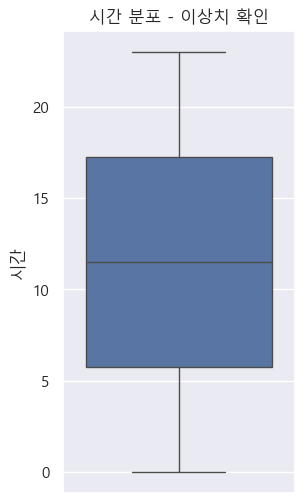

In [113]:
plt.figure(figsize=(3, 6))
sns.boxplot(data=power_df['시간'])
plt.title('시간 분포 - 이상치 확인')
plt.show()

In [114]:
power_df.corr()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
날짜,1.000000e+00,-5.187585e-14,0.035555,0.034746,0.037285,0.036244,0.036572,0.070719,0.863028,-0.267877,0.548722,0.160855,8.358358e-01,-1.183774e-02,-3.521020e-02,9.993569e-01,-0.002136,0.005469
시간,-5.187585e-14,1.000000e+00,0.124191,0.112568,0.101041,0.076296,0.104344,0.132111,0.109343,0.097169,-0.145032,0.122523,1.083940e-15,-5.182983e-18,3.872564e-18,1.634985e-15,0.084077,-0.166807
15분,3.555450e-02,1.241908e-01,1.000000,0.980295,0.966859,0.950034,0.984688,0.520424,0.050760,0.115016,-0.085205,-0.008241,5.588134e-02,-4.283119e-01,5.255441e-02,3.360101e-02,0.295909,-0.202557
30분,3.474601e-02,1.125677e-01,0.980295,1.000000,0.982443,0.959004,0.991255,0.515841,0.049524,0.113965,-0.084102,-0.010410,5.620322e-02,-4.266740e-01,5.575440e-02,3.267924e-02,0.288622,-0.195760
45분,3.728511e-02,1.010415e-01,0.966859,0.982443,1.000000,0.984789,0.994774,0.513789,0.052818,0.115627,-0.082522,-0.013136,5.904420e-02,-4.329573e-01,5.604744e-02,3.520298e-02,0.286091,-0.211635
60분,3.624374e-02,7.629631e-02,0.950034,0.959004,0.984789,1.000000,0.984828,0.499723,0.055651,0.128467,-0.090875,-0.014812,5.787812e-02,-4.375765e-01,5.635399e-02,3.415260e-02,0.276778,-0.243434
평균,3.657182e-02,1.043443e-01,0.984688,0.991255,0.994774,0.984828,1.000000,0.517948,0.052996,0.119667,-0.086508,-0.011759,5.809601e-02,-4.362798e-01,5.582355e-02,3.449909e-02,0.289860,-0.215982
생산량,7.071926e-02,1.321111e-01,0.520424,0.515841,0.513789,0.499723,0.517948,1.000000,0.117780,0.115388,-0.109503,0.008171,6.892961e-02,-2.591290e-01,4.483612e-02,6.897566e-02,0.785115,-0.280625
기온,8.630283e-01,1.093433e-01,0.050760,0.049524,0.052818,0.055651,0.052996,0.117780,1.000000,-0.192028,0.401553,0.118524,8.098254e-01,1.012953e-02,1.084866e-01,8.574903e-01,0.030540,-0.184611
풍속,-2.678775e-01,9.716902e-02,0.115016,0.113965,0.115627,0.128467,0.119667,0.115388,-0.192028,1.000000,-0.439745,0.049009,-2.541913e-01,3.896542e-03,-1.190186e-02,-2.669439e-01,0.088701,-0.349769


In [103]:
power_df.corr()['평균']

날짜          0.036572
시간          0.104344
15분         0.984688
30분         0.991255
45분         0.994774
60분         0.984828
평균          1.000000
생산량         0.517948
기온          0.052996
풍속          0.119667
습도         -0.086508
강수량        -0.011759
전기요금(계절)    0.058096
day        -0.436280
d           0.055824
m           0.034499
공장인원        0.289860
인건비        -0.215982
Name: 평균, dtype: float64

## 2.3 데이터 현황 조사 : 전력량과 다른 변수들간의 상관관계 
- 우선 15, 30, 45, 60, 평균은 서로 깊은 연관 : 당연한 결과
- 평균전력량을 기준으로 생산량과 연관; 다만 0.52 수준으로 그리 높지는 않음 - 고정 전력량, 공장인원과 생산량과의 상관관계 등의 영향 의심
- 기온, 풍속은은 상대적으로 낮음 (계절별 확인 필요)
- 요일(day)와는 음의 상관관계 : 6, 7 이 토, 일 평일이 1,2,3,4,5 => 주중에 생산량이 높은 것과 연관
- 공장인원은 생산량과 연관되어 같이 높을 수도... : 생산량과 공장인원은 0.785

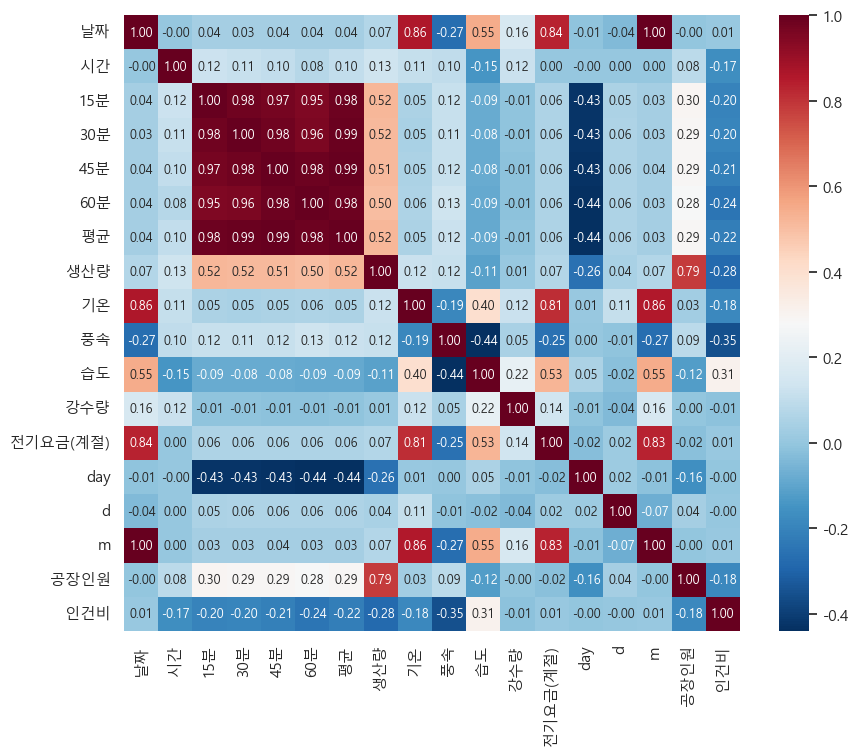

In [14]:
# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.figure(figsize=(10, 8)) # 화면 크기 확대 (가로 10, 세로 8)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 2. Seaborn 스타일 설정 (set_theme 사용 권장)
sns.set_theme(style="darkgrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

# 3. 히트맵 그리기
sns.heatmap(
    power_df.corr(), 
    vmax=1, 
    square=True, 
    annot=True, 
    fmt=".2f",          # 소수점 둘레 설정으로 가독성 향상
    annot_kws={'size': 9}, # 글자 크기를 5에서 9로 키움
    cmap='RdBu_r'       # 상관계수 확인에 용이한 컬러맵 추가 (선택사항)
)

plt.show()

### 생산량과 인건비 상관관계 확인

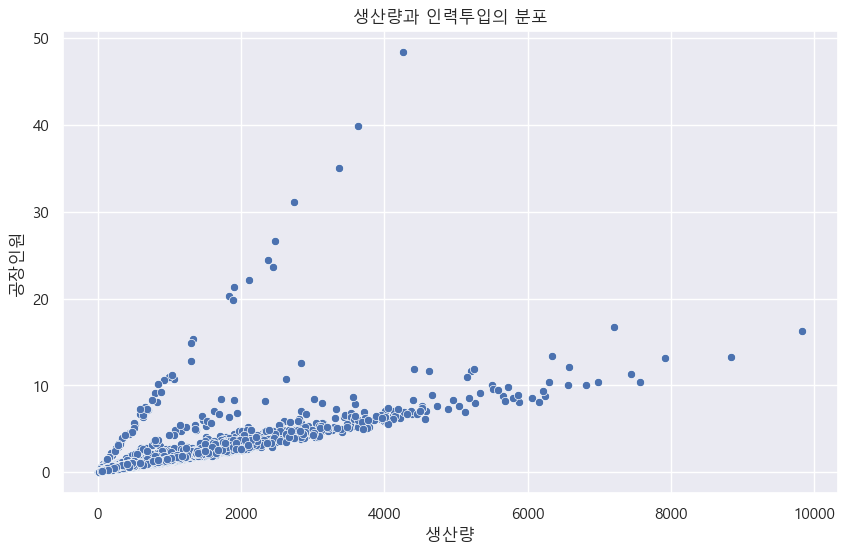

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 깨짐 방지 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=power_df, x='생산량', y='공장인원')

plt.title('생산량과 인력투입의 분포')
plt.grid(True)
plt.show()


인력과 생산량 관계에 따라 3개의 그룹으로 분류 

In [104]:
power_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


## 비지도 군집화  - GaussianMixture 이용
- 선형적 상관관계가 있는 그룹들을 묶기 위해 기울기를 기준으로 그룹화

In [40]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture

# 1. 데이터 분리 및 분석용 기울기 계산
mask_zero = power_df['생산량'] <= 0
df_na = power_df[mask_zero].copy()
df_na['생산구분'] = -1

df_target = power_df[~mask_zero].copy()
# '생산인력비율' 계산 (제품 100개당 투입 인원)
df_target['생산인력비율'] = df_target['공장인원'] / (df_target['생산량'] / 100)

# 2. GMM 분류 및 초기 라벨링 (4, 2, 1)
X_ratio = df_target[['생산인력비율']].values

# 2.2 로그 변환 (Log Transformation)
# 비율 데이터의 이분산성을 줄여 하단 그룹 간의 '거리'를 확보합니다.
# np.log1p는 log(1+x)로, 혹시 모를 0값에 대한 오류를 방지합니다.
X_log = np.log1p(X_ratio)
  
# 3. GMM 모델 생성 및 학습
# 1차원 데이터이므로 covariance_type은 기본값('full')을 유지해도 무방합니다.
gmm = GaussianMixture(
    n_components=3, 
    n_init=20, 
    covariance_type='full', 
    random_state=42
)

gmm = GaussianMixture(n_components=3, n_init=20, random_state=42)
df_target['cluster'] = gmm.fit_predict(X_log)

# 4. 결과 매핑 (기울기 평균이 높은 순서대로 4, 2, 1 부여)
# 로그 변환된 값이 아닌 원본 '생산인력비율'의 평균으로 그룹 순서를 결정합니다.
cluster_avg = df_target.groupby('cluster')['생산인력비율'].mean().sort_values(ascending=False)
    
# label_map 생성: 가장 높은 비율 그룹(4), 중간(2), 가장 낮은 비율 그룹(1)
label_map = {
    cluster_avg.index[0]: 4, 
    cluster_avg.index[1]: 2, 
    cluster_avg.index[2]: 1
    }
df_target['생산구분'] = df_target['cluster'].map(label_map)

# 재분류 전 그룹별 사이즈
print(df_target['생산구분'].value_counts())

# [출력 1] 재분류 전 통계 (순수 GMM 결과)
print("\n" + "="*50)
print("[1. 재분류 전 통계 (Pure GMM + Log Trans)]")
before_stats = df_target.groupby('생산구분')['생산인력비율'].agg(['mean', lambda x: x.quantile(0.75)]).rename(columns={'<lambda_0>': '3Q'})
print(before_stats)

# 4. [정밀 재분류] 중간(2) 그룹의 75% 지점 * 1.15 적용
middle_q3 = df_target.loc[df_target['생산구분'] == 2, '생산인력비율'].quantile(0.75)
threshold = middle_q3 * 1.15
reassign_mask = (df_target['생산구분'] == 2) & (df_target['생산인력비율'] <= threshold)
df_target.loc[reassign_mask, '생산구분'] = 1

# 4. 결과 통합 및 데이터프레임 정리
# (1) power_df: 기존 모든 컬럼 유지 + '생산구분'만 추가
# 모든 행의 라벨을 하나로 합친 뒤, 원본 power_df에 인덱스 기준으로 붙입니다.
all_labels = pd.concat([df_target[['생산구분']], df_na[['생산구분']]]).sort_index()
power_df['생산구분'] = all_labels['생산구분']

# (2) product_df: 요청하신 5개 컬럼만 추출
product_df = df_target[['생산량', '공장인원', '생산인력비율', 'cluster', '생산구분', '평균']].copy()

# print("분류 및 데이터 통합 완료!")
# print(f"power_df 컬럼 목록: {power_df.columns.tolist()}")
# print(f"product_df 컬럼 목록: {product_df.columns.tolist()}")

print("-"*80)
print("재분류 후 데이터 분포")
print(df_target['생산구분'].value_counts())
# [출력 2] 재분류 후 통계
print("\n" + "="*50)
print(f"[2. 재분류 후 통계 (Threshold: {threshold:.4f} 적용)]")
after_stats = df_target.groupby('생산구분')['생산인력비율'].agg(['mean', lambda x: x.quantile(0.75)]).rename(columns={'<lambda_0>': '3Q'})
print(after_stats)
print("="*50)


생산구분
2    2106
1    1308
4      97
Name: count, dtype: int64

[1. 재분류 전 통계 (Pure GMM + Log Trans)]
          mean        3Q
생산구분                    
1     0.150097  0.157480
2     0.235225  0.248139
4     1.093639  1.136364
--------------------------------------------------------------------------------
재분류 후 데이터 분포
생산구분
1    3232
2     182
4      97
Name: count, dtype: int64

[2. 재분류 후 통계 (Threshold: 0.2854 적용)]
          mean        3Q
생산구분                    
1     0.193654  0.232019
2     0.361657  0.396433
4     1.093639  1.136364


In [28]:
product_df.info() 
product_df

<class 'pandas.DataFrame'>
Index: 3511 entries, 80 to 6167
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   생산량      3511 non-null   int64  
 1   공장인원     3511 non-null   float64
 2   생산인력비율   3511 non-null   float64
 3   cluster  3511 non-null   int64  
 4   생산구분     3511 non-null   int64  
 5   평균       3511 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 192.0 KB


,생산량,공장인원,생산인력비율,cluster,생산구분,평균
80,165,0.264000,0.160000,2,1,156
81,313,0.488300,0.156006,2,1,160
82,2757,4.404153,0.159744,2,1,157
83,983,1.652101,0.168067,2,1,149
84,96,0.268908,0.280112,0,1,89
...,...,...,...,...,...,...
6163,1497,2.442088,0.163132,2,1,153
6164,45,0.087891,0.195312,0,1,128
6165,149,0.290448,0.194932,0,1,128
6166,66,0.148984,0.225734,0,1,111


In [32]:
product_df['생산구분'].value_counts()

생산구분
1    3232
2     182
4      97
Name: count, dtype: int64

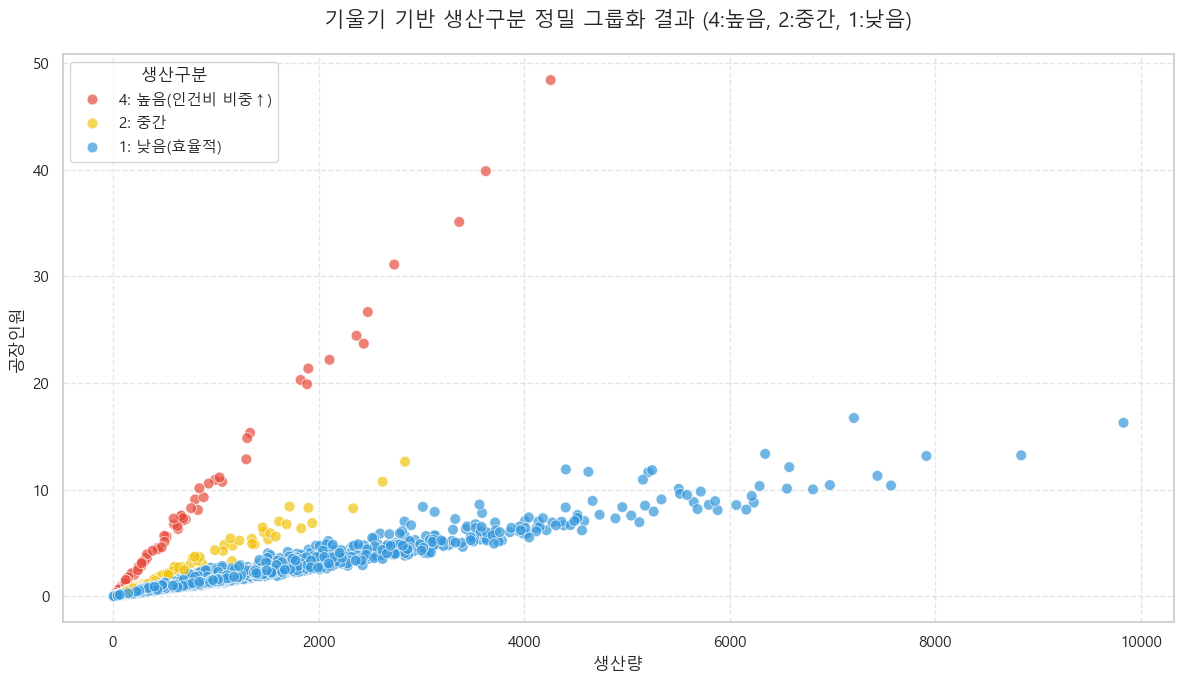

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화용 데이터 준비 (N/A인 -1 제외)
plot_df = power_df[power_df['생산구분'] != -1].copy()

# 2. 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 3. 산점도 시각화
plt.figure(figsize=(12, 7))

# 숫자 라벨에 따른 색상 및 순서 지정 (4:높음, 2:중간, 1:낮음)
palette = {4: '#e74c3c', 2: '#f1c40f', 1: '#3498db'}
hue_order = [4, 2, 1]

sns.scatterplot(
    data=plot_df, 
    x='생산량', 
    y='공장인원', 
    hue='생산구분', 
    hue_order=hue_order,
    palette=palette,
    alpha=0.7,
    edgecolor='w',
    s=60
)

# 4. 그래프 꾸미기 (범례 텍스트 커스텀)
plt.title('기울기 기반 생산구분 정밀 그룹화 결과 (4:높음, 2:중간, 1:낮음)', fontsize=15, pad=20)
plt.xlabel('생산량', fontsize=12)
plt.ylabel('공장인원', fontsize=12)

# 범례에 숫자와 의미를 명시적으로 표시
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['4: 높음(인건비 비중↑)', '2: 중간', '1: 낮음(효율적)'], 
           title='생산구분', loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [19]:
df_target

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,...,강수량,전기요금(계절),day,d,m,공장인원,인건비,생산인력비율,cluster,생산구분
80,20210104,8,154,153,159,159,156,165,-2.7,4.1,...,0.0,109.8,1,4,1,0.264000,1.5,0.160000,0,1
81,20210104,9,158,158,159,166,160,313,-1.5,2.4,...,0.0,109.8,1,4,1,0.488300,1.0,0.156006,0,1
82,20210104,10,127,158,173,168,157,2757,0.4,2.4,...,0.0,109.8,1,4,1,4.404153,1.0,0.159744,0,1
83,20210104,11,141,150,155,149,149,983,2.1,2.5,...,0.0,109.8,1,4,1,1.652101,1.0,0.168067,0,1
84,20210104,12,81,64,94,118,89,96,4.0,3.3,...,0.0,109.8,1,4,1,0.268908,1.0,0.280112,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,...,9.4,167.2,2,14,9,2.442088,1.5,0.163132,0,1
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,...,9.4,167.2,2,14,9,0.087891,1.5,0.195312,2,1
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,...,9.4,167.2,2,14,9,0.290448,1.5,0.194932,2,1
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,...,9.4,167.2,2,14,9,0.148984,1.5,0.225734,2,1


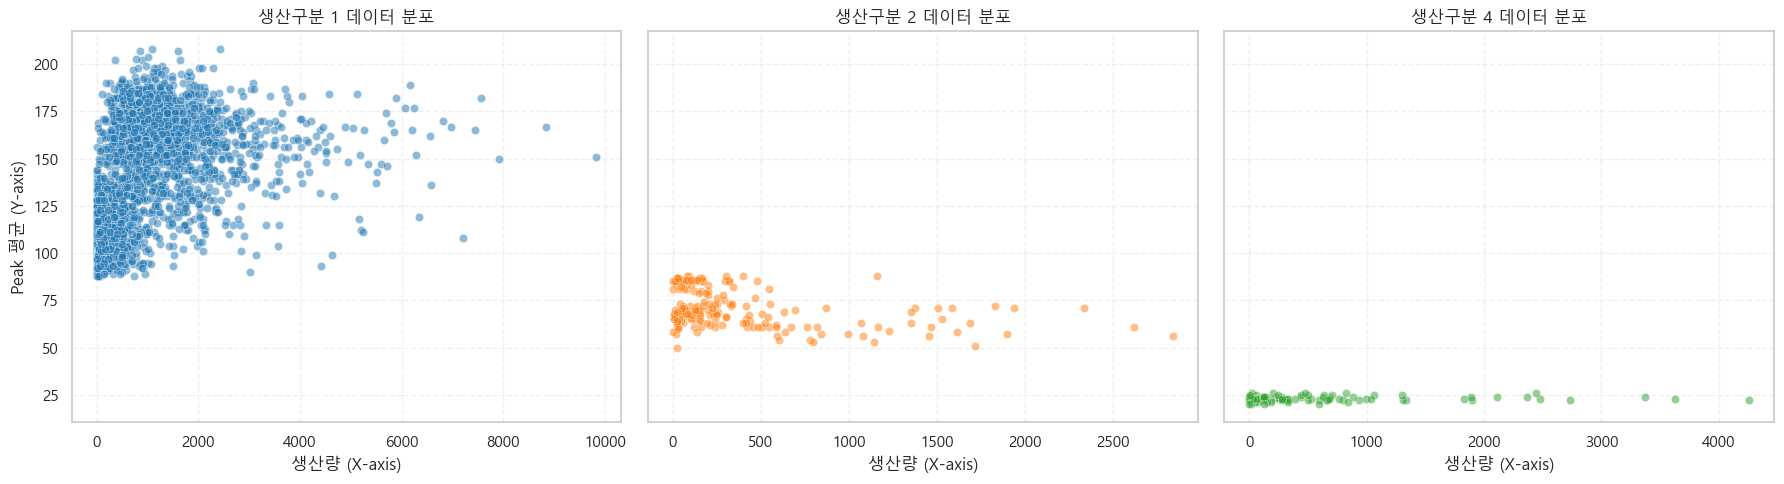

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 대상 생산구분 및 색상 설정
categories = [1, 2, 4]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 파랑, 주황, 초록

# 1행 3열 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, cat in enumerate(categories):
    # 해당 생산구분 데이터 추출
    df_sub = product_df[product_df['생산구분'] == cat]
    
    # 산포도 그리기 (생산량: x축, 평균: y축)
    sns.scatterplot(data=df_sub, x='생산량', y='평균', 
                    ax=axes[i], color=colors[i], alpha=0.5)
    
    axes[i].set_title(f'생산구분 {cat} 데이터 분포')
    axes[i].set_xlabel('생산량 (X-axis)')
    axes[i].set_ylabel('Peak 평균 (Y-axis)' if i == 0 else '')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [133]:
power_df['생산량'].max()

np.int64(9830)

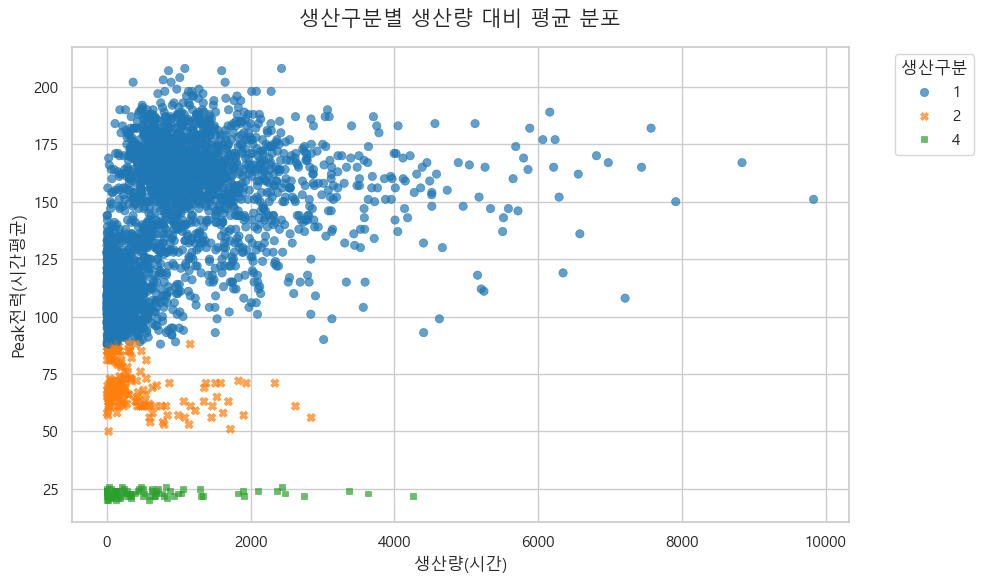

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 필터링 및 설정값 정의
categories = [1, 2, 4]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 요청하신 파랑, 주황, 초록
target_df = product_df[product_df['생산구분'].isin(categories)]

# 3. 산포도 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=target_df, 
    x='생산량', 
    y='평균', 
    hue='생산구분', 
    palette=colors,      # 정의한 색상 리스트 적용
    hue_order=categories, # 색상 순서 고정
    style='생산구분', 
    alpha=0.7, 
    edgecolor=None
)

# 4. 타이틀 및 라벨 설정
plt.title('생산구분별 생산량 대비 평균 분포', fontsize=15, pad=15)
plt.xlabel('생산량(시간)', fontsize=12)
plt.ylabel('Peak전력(시간평균)', fontsize=12)
plt.legend(title='생산구분', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


In [23]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture

def classify_production_efficiency(power_df):
    """
    생산량 대비 인력 투입 비율을 로그 변환 후 GMM으로 3개 그룹 분류하는 모듈
    """
    # 1. 데이터 전처리 (생산량이 0인 데이터 분리)
    mask_zero = power_df['생산량'] <= 0
    df_na = power_df[mask_zero].copy()
    df_na['생산구분'] = -1
    
    df_target = power_df[~mask_zero].copy()
    
    # '생산인력비율' 계산 (기울기 추출)
    df_target['생산인력비율'] = df_target['공장인원'] / (df_target['생산량'] / 100)
    
    # 2. 로그 변환 (Log Transformation)
    # 비율 데이터의 이분산성을 줄여 하단 그룹 간의 '거리'를 확보합니다.
    # np.log1p는 log(1+x)로, 혹시 모를 0값에 대한 오류를 방지합니다.
    X_ratio = df_target[['생산인력비율']].values
    X_log = np.log1p(X_ratio)
    
    # 3. GMM 모델 생성 및 학습
    # 1차원 데이터이므로 covariance_type은 기본값('full')을 유지해도 무방합니다.
    gmm = GaussianMixture(
        n_components=3, 
        n_init=20, 
        covariance_type='full', 
        random_state=42
    )
    df_target['cluster'] = gmm.fit_predict(X_log)
    
    # 4. 결과 매핑 (기울기 평균이 높은 순서대로 4, 2, 1 부여)
    # 로그 변환된 값이 아닌 원본 '생산인력비율'의 평균으로 그룹 순서를 결정합니다.
    cluster_avg = df_target.groupby('cluster')['생산인력비율'].mean().sort_values(ascending=False)
    
    # label_map 생성: 가장 높은 비율 그룹(4), 중간(2), 가장 낮은 비율 그룹(1)
    label_map = {
        cluster_avg.index[0]: 4, 
        cluster_avg.index[1]: 2, 
        cluster_avg.index[2]: 1
    }
    df_target['생산구분'] = df_target['cluster'].map(label_map)
    
    # 5. 결과 통합 및 반환
    all_results = pd.concat([df_target, df_na]).sort_index()
    
    # 분석용 요약 정보 출력
    print("--- GMM 분류 결과 요약 (로그 변환 적용) ---")
    summary = df_target.groupby('생산구분')['생산인력비율'].agg(['mean', 'min', 'max', 'count'])
    print(summary)
    
    return all_results

# --- 사용 예시 ---
# result_df = classify_production_efficiency(power_df)


In [24]:
result_df = classify_production_efficiency(power_df)

--- GMM 분류 결과 요약 (로그 변환 적용) ---
          mean       min       max  count
생산구분                                     
1     0.150097  0.125471  0.168919   1308
2     0.235225  0.120482  0.500000   2106
4     1.093639  0.970874  1.250000     97


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

def run_gmm_and_visualize(df):
    # 1. 전처리 (생산량이 0인 데이터 제외)
    df_target = df[df['생산량'] > 0].copy()
    
    # 기울기(생산인력비율) 계산
    df_target['생산인력비율'] = df_target['공장인원'] / (df_target['생산량'] / 100)
    
    # 2. 로그 변환 적용
    # 하단 밀집 지역의 해상도를 높여 GMM이 더 잘 구분하게 합니다.
    X_ratio = df_target[['생산인력비율']].values
    X_log = np.log1p(X_ratio)
    
    # 3. GMM 모델링 (n_components=3)
    gmm = GaussianMixture(n_components=3, n_init=20, random_state=42)
    df_target['cluster'] = gmm.fit_predict(X_log)
    
    # 4. 평균 기울기에 따른 라벨 매핑 (4: 고인력, 2: 중인력, 1: 저인력)
    # 로그 변환 전 원본 비율의 평균으로 그룹 순서를 정합니다.
    cluster_means = df_target.groupby('cluster')['생산인력비율'].mean().sort_values(ascending=False)
    label_map = {cluster_means.index[0]: 4, cluster_means.index[1]: 2, cluster_means.index[2]: 1}
    df_target['생산구분'] = df_target['cluster'].map(label_map)
    
    # --- 시각화 ---
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # 색상 팔레트 설정 (구분이 잘 되도록 설정)
    palette = {4: 'red', 2: 'orange', 1: 'blue'}
    
    # 산점도 그리기
    sns.scatterplot(
        data=df_target, 
        x='생산량', 
        y='공장인원', 
        hue='생산구분', 
        palette=palette,
        alpha=0.7,
        edgecolor='w'
    )
    
    # 각 그룹의 경계(기울기) 확인을 위한 대강의 가이드 라인 추가 (선택사항)
    for label in [1, 2, 4]:
        max_ratio = df_target[df_target['생산구분'] == label]['생산인력비율'].max()
        x_vals = np.array([0, df_target['생산량'].max()])
        y_vals = (max_ratio / 100) * x_vals
        plt.plot(x_vals, y_vals, '--', color=palette[label], alpha=0.3, label=f'Group {label} Boundary')

    plt.title('GMM Clustering Result (Log-Transformed Ratios)', fontsize=15)
    plt.xlabel('Production (생산량)', fontsize=12)
    plt.ylabel('Factory Workers (공장인원)', fontsize=12)
    plt.legend(title='Production Type (생산구분)')
    plt.show()
    
    # 결과 요약 출력
    summary = df_target.groupby('생산구분')['생산인력비율'].agg(['mean', 'min', 'max', 'count'])
    print("\n[분류 결과 요약]")
    print(summary)
    
    return df_target

# 실행 (power_df가 정의되어 있다고 가정)
# result_df = run_gmm_and_visualize(power_df)


c:\Apps\MiniConda\envs\ml_power\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Apps\MiniConda\envs\ml_power\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Apps\MiniConda\envs\ml_power\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Apps\MiniConda\envs\ml_power\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Apps\MiniConda\envs\ml_power\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_fi

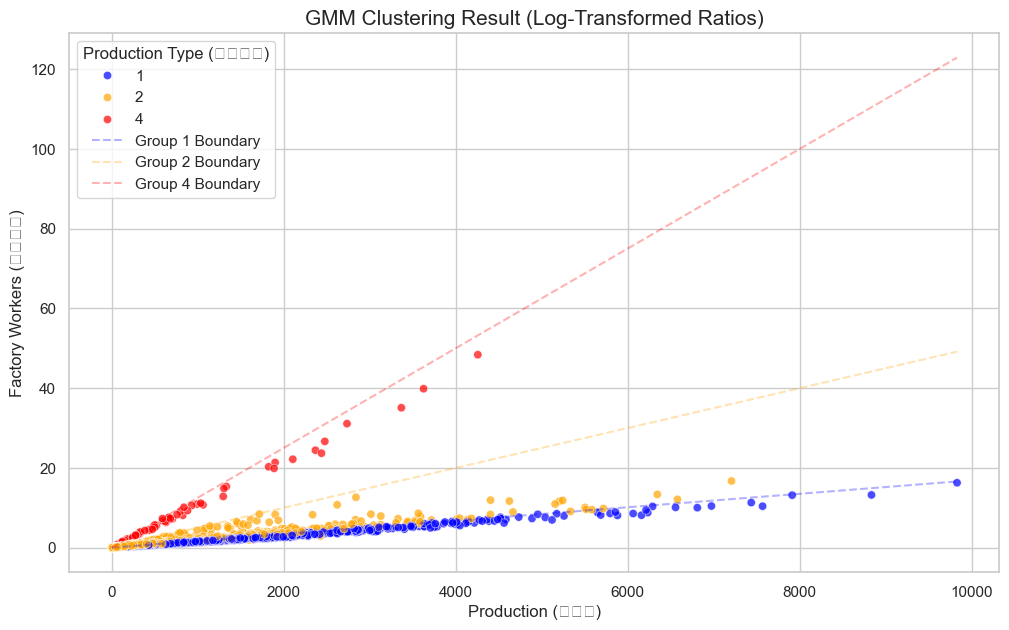


[분류 결과 요약]
          mean       min       max  count
생산구분                                     
1     0.150097  0.125471  0.168919   1308
2     0.235225  0.120482  0.500000   2106
4     1.093639  0.970874  1.250000     97


In [26]:
result_df = run_gmm_and_visualize(power_df)


In [247]:
product_df[product_df['생산구분']==2].describe()

,생산량,공장인원,생산인력비율,cluster,생산구분,평균
count,182.000000,182.000000,182.000000,182.0,182.0,182.000000
mean,398.318681,1.541969,0.361657,2.0,2.0,70.620879
std,530.557361,2.174893,0.050006,0.0,0.0,9.891355
min,1.000000,0.002959,0.285714,2.0,2.0,50.000000
25%,67.000000,0.231444,0.312500,2.0,2.0,63.000000
50%,176.000000,0.604804,0.362319,2.0,2.0,69.000000
75%,481.500000,1.833406,0.396433,2.0,2.0,80.000000
max,2841.000000,12.626667,0.500000,2.0,2.0,88.000000


In [48]:
power_df[power_df['생산구분']==-1]['평균'].describe()

count    2657.000000
mean       46.188935
std        43.981587
min         0.000000
25%        22.000000
50%        23.000000
75%        61.000000
max       198.000000
Name: 평균, dtype: float64

최빈값: 0    23
Name: 평균, dtype: int64


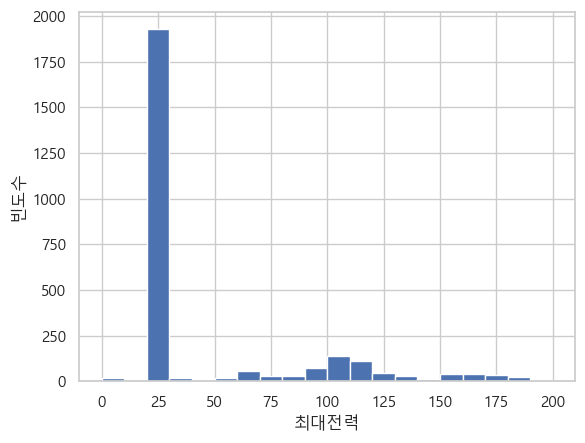

In [58]:
# 생산량이 0 인 경우의 최대전력량 분포
df = power_df[power_df['생산량']==0]['평균']
print("최빈값:", df.mode())

# 0부터 200까지 10씩 증가하는 리스트 생성 [0, 10, 20, ..., 200]
custom_bins = np.arange(0, 201, 10)

plt.hist(df, bins=custom_bins)
plt.xlabel("최대전력")
plt.ylabel("빈도수")
plt.show()

최빈값:
 0    23
Name: 평균, dtype: int64


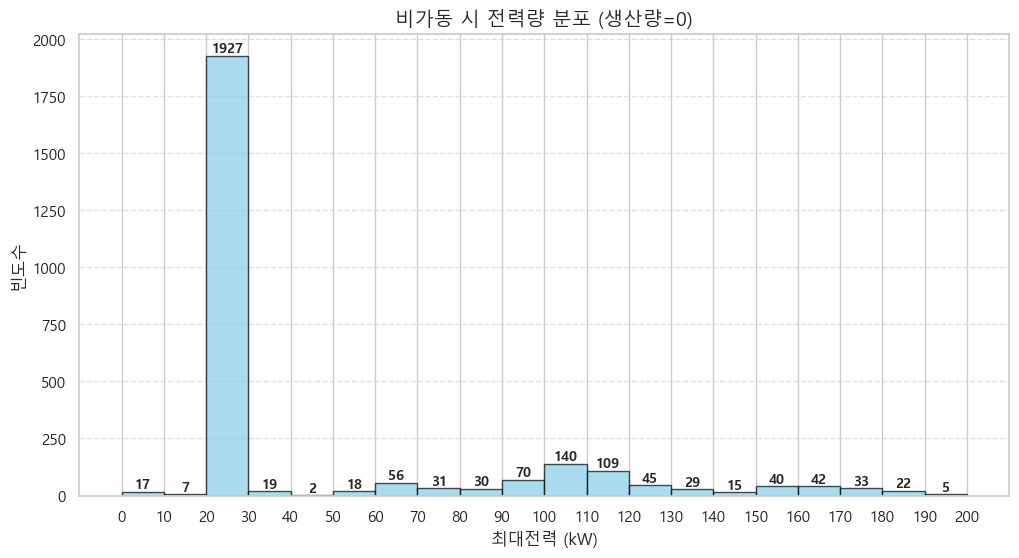

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 추출 및 최빈값 확인
df_zero = power_df[power_df['생산량'] == 0]['평균']
print("최빈값:\n", df_zero.mode())

# 2. 히스토그램 설정
custom_bins = np.arange(0, 201, 10)

plt.figure(figsize=(12, 6))

# plt.hist는 n(빈도수), bins(경계값), patches(그래프 객체)를 반환합니다.
n, bins, patches = plt.hist(df_zero, bins=custom_bins, color='skyblue', edgecolor='black', alpha=0.7)

# 3. 각 막대(patch) 위에 빈도수 표시
for i in range(len(n)):
    # 빈도수가 0보다 큰 경우에만 표시 (그래프가 깔끔해짐)
    if n[i] > 0:
        # x 좌표: 막대의 중간 지점, y 좌표: 막대의 높이(빈도수)
        plt.text(bins[i] + 5, n[i] + 0.5, int(n[i]), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("비가동 시 전력량 분포 (생산량=0)", fontsize=14)
plt.xlabel("최대전력 (kW)")
plt.ylabel("빈도수")
plt.xticks(custom_bins) # x축 눈금을 bins 간격과 맞춤
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


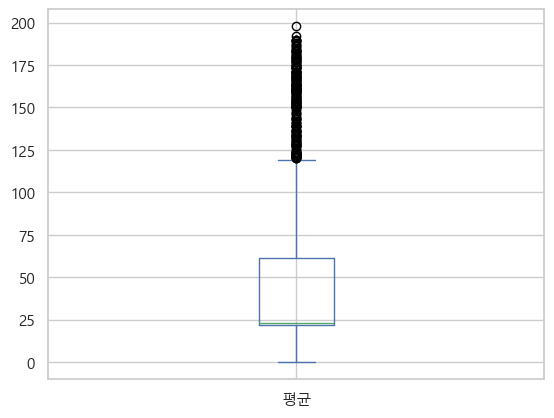

In [52]:
# 생산량이 0 인 경우의 최대전력량 분포
df = power_df[power_df['생산량']==0]['평균']
df.plot(kind='box')
plt.show()

비가동 시 전체 평균 전력량: 46.19 kW


C:\Users\Admin\AppData\Local\Temp\ipykernel_13416\2079622588.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")


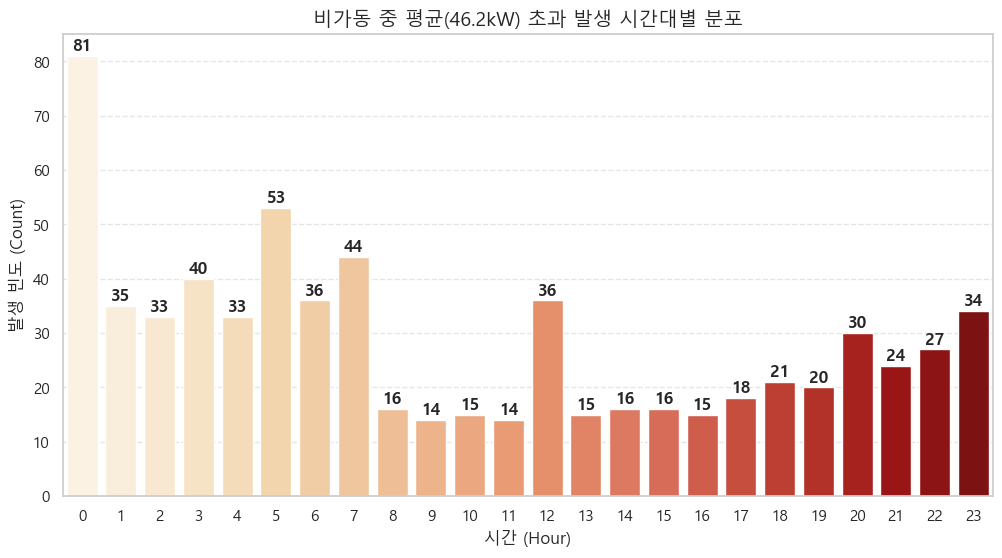

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 생산량이 0인 데이터만 추출
df_zero = power_df[power_df['생산량'] == 0].copy()

# 2. 비가동 시 전력량의 전체 평균 계산 (기준값)
zero_power_mean = df_zero['평균'].mean()
print(f"비가동 시 전체 평균 전력량: {zero_power_mean:.2f} kW")

# 3. 평균을 초과하는 '이상 전력' 데이터만 필터링
# (평균을 넘어서는 경우의 '빈도'를 보고 싶다면 count, '총량'을 보고 싶다면 sum 사용)
df_over_mean = df_zero[df_zero['평균'] > zero_power_mean]

# 4. 시간대(0~23)별로 그룹화하여 빈도수(횟수) 계산
hourly_dist = df_over_mean.groupby('시간')['평균'].count().reindex(range(24), fill_value=0)

# --- 시각화 ---
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")

# 각 막대 위에 수치 표시
for i, v in enumerate(hourly_dist.values):
    if v > 0:
        plt.text(i, v + 0.2, int(v), ha='center', va='bottom', fontweight='bold')

plt.title(f"비가동 중 평균({zero_power_mean:.1f}kW) 초과 발생 시간대별 분포", fontsize=14)
plt.xlabel("시간 (Hour)", fontsize=12)
plt.ylabel("발생 빈도 (Count)", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


비가동 시 전체 평균 전력량: 46.19 kW
비가동 시 전체 최빈 전력량: 23.00 kW


C:\Users\Admin\AppData\Local\Temp\ipykernel_13416\851375045.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")


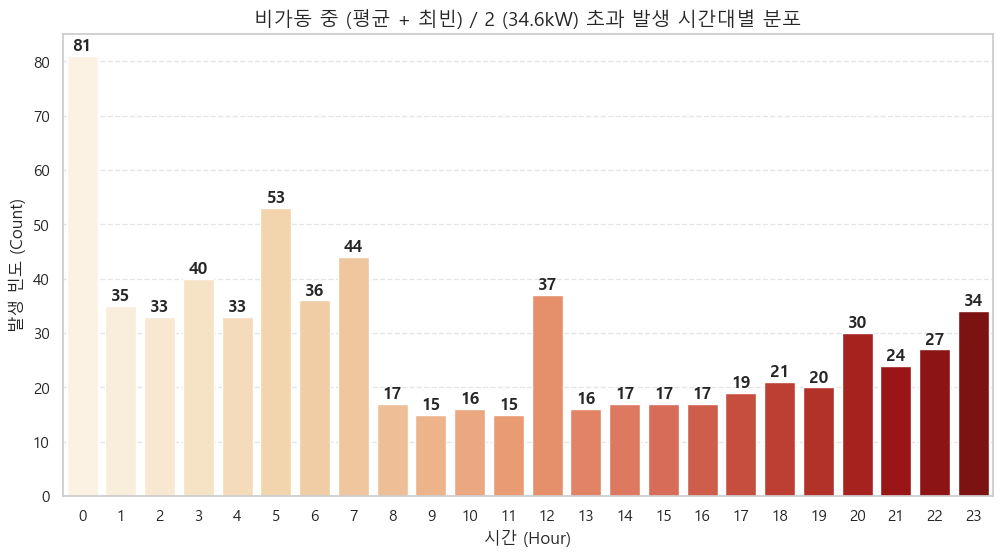

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 생산량이 0인 데이터만 추출
df_zero = power_df[power_df['생산량'] == 0].copy()

# 2. 비가동 시 전력량의 전체 평균 계산 (기준값)
zero_power_mode = df_zero['평균'].mode()[0]
zero_power_mean = df_zero['평균'].mean()

print(f"비가동 시 전체 평균 전력량: {zero_power_mean:.2f} kW")
print(f"비가동 시 전체 최빈 전력량: {zero_power_mode:.2f} kW")

zero_power_half = (zero_power_mode + zero_power_mean) / 2 

# 3. 평균을 초과하는 '이상 전력' 데이터만 필터링
# (평균을 넘어서는 경우의 '빈도'를 보고 싶다면 count, '총량'을 보고 싶다면 sum 사용)
df_over_mean = df_zero[df_zero['평균'] > zero_power_half]

# 4. 시간대(0~23)별로 그룹화하여 빈도수(횟수) 계산
hourly_dist = df_over_mean.groupby('시간')['평균'].count().reindex(range(24), fill_value=0)

# --- 시각화 ---
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")

# 각 막대 위에 수치 표시
for i, v in enumerate(hourly_dist.values):
    if v > 0:
        plt.text(i, v + 0.2, int(v), ha='center', va='bottom', fontweight='bold')

plt.title(f"비가동 중 (평균 + 최빈) / 2 ({zero_power_half:.1f}kW) 초과 발생 시간대별 분포", fontsize=14)
plt.xlabel("시간 (Hour)", fontsize=12)
plt.ylabel("발생 빈도 (Count)", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

비가동 시 전체 3Q 전력량: 61.00 kW


C:\Users\Admin\AppData\Local\Temp\ipykernel_13416\636828091.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")


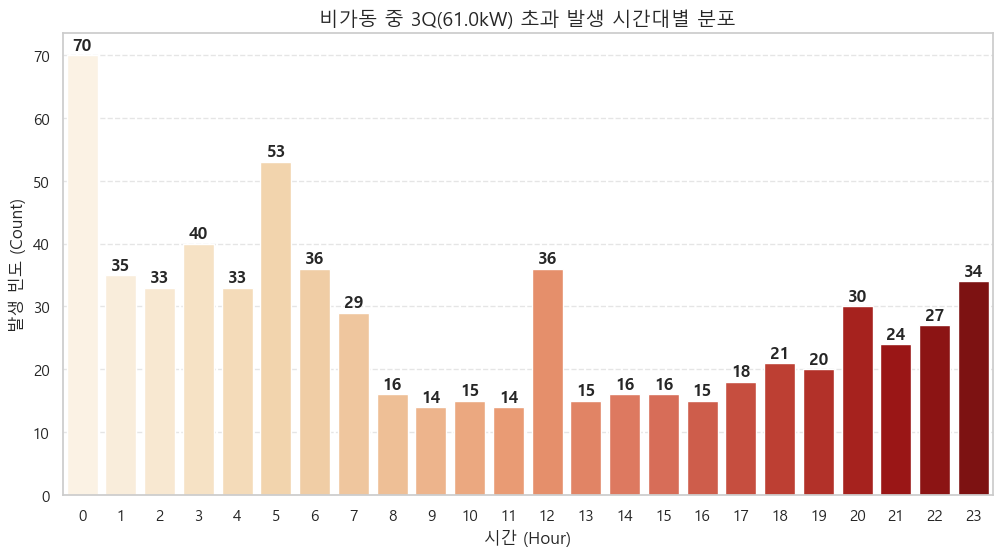

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 생산량이 0인 데이터만 추출
df_zero = power_df[power_df['생산량'] == 0].copy()

# 2. 비가동 시 전력량의 전체 평균 계산 (기준값)
zero_power_3q = df_zero['평균'].quantile(0.75)
print(f"비가동 시 전체 3Q 전력량: {zero_power_3q:.2f} kW")

# 3. 평균을 초과하는 '이상 전력' 데이터만 필터링
# (평균을 넘어서는 경우의 '빈도'를 보고 싶다면 count, '총량'을 보고 싶다면 sum 사용)
df_over_mean = df_zero[df_zero['평균'] > zero_power_3q]

# 4. 시간대(0~23)별로 그룹화하여 빈도수(횟수) 계산
hourly_dist = df_over_mean.groupby('시간')['평균'].count().reindex(range(24), fill_value=0)

# --- 시각화 ---
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_dist.index, y=hourly_dist.values, palette="OrRd")

# 각 막대 위에 수치 표시
for i, v in enumerate(hourly_dist.values):
    if v > 0:
        plt.text(i, v + 0.2, int(v), ha='center', va='bottom', fontweight='bold')

plt.title(f"비가동 중 3Q({zero_power_3q:.1f}kW) 초과 발생 시간대별 분포", fontsize=14)
plt.xlabel("시간 (Hour)", fontsize=12)
plt.ylabel("발생 빈도 (Count)", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

기준값: 34.59446744448626


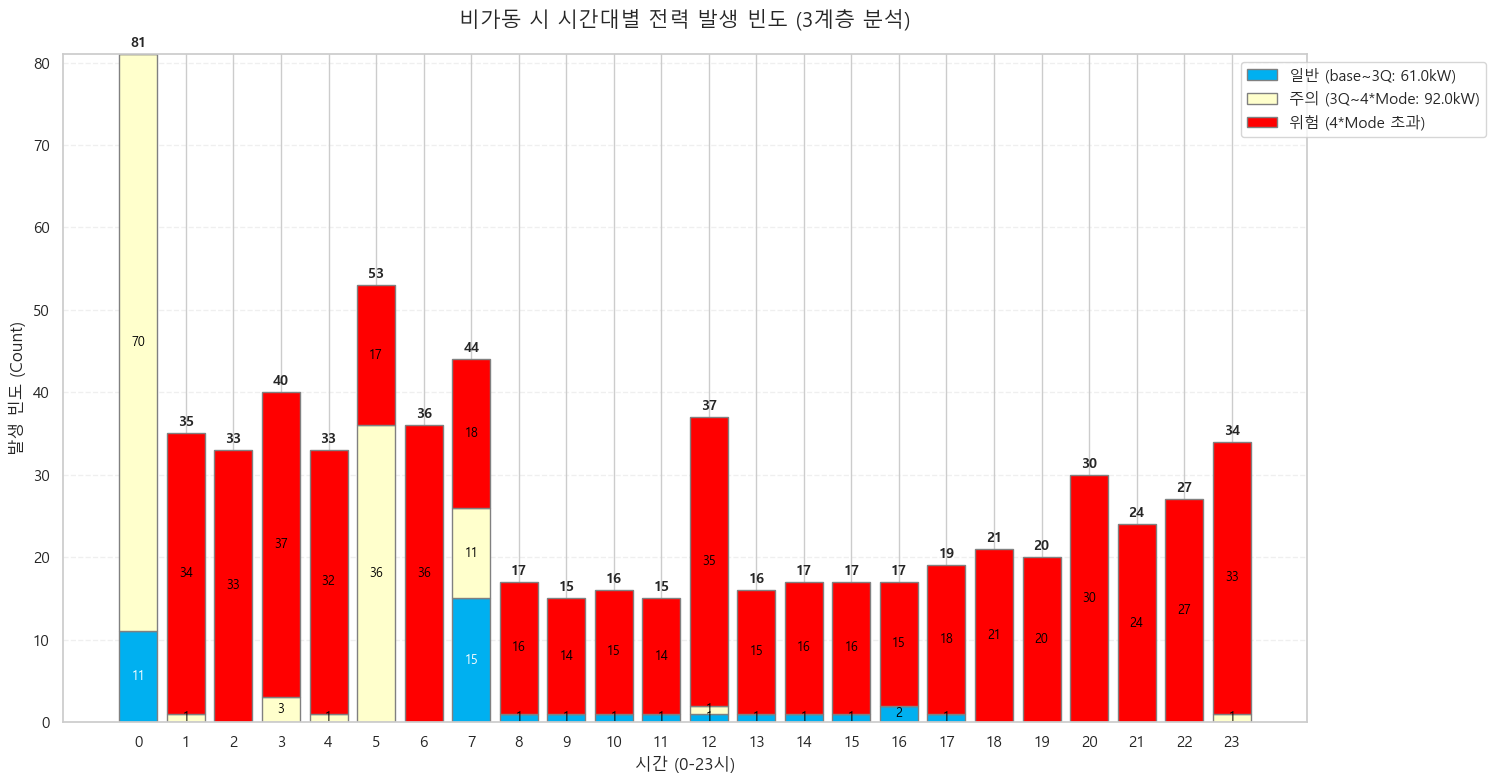

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 필터링 및 기준값 계산
df_zero = power_df[power_df['생산량'] == 0].copy()

mode_val = df_zero['평균'].mode()[0]
mean_val = df_zero['평균'].mean()
base_val = (mode_val + mean_val) / 2
print("기준값:", base_val)
q3_val = df_zero['평균'].quantile(0.75)
high_val = 4 * mode_val

# 2. 3계층 빈도 계산 (구간 설정)
dist_under = df_zero[(df_zero['평균'] > base_val) & (df_zero['평균'] <= q3_val)].groupby('시간')['평균'].count().reindex(range(24), fill_value=0)
dist_middle = df_zero[(df_zero['평균'] > q3_val) & (df_zero['평균'] <= high_val)].groupby('시간')['평균'].count().reindex(range(24), fill_value=0)
dist_over = df_zero[df_zero['평균'] > high_val].groupby('시간')['평균'].count().reindex(range(24), fill_value=0)

# 3. 누적 막대 그래프 시각화
plt.figure(figsize=(15, 8))

# 계층 1: 아래쪽 (파란색)
plt.bar(range(24), dist_under, color='#00B0F0', label=f'일반 (base~3Q: {q3_val:.1f}kW)', edgecolor='grey')

# 계층 2: 중간 (노란색) - bottom에 dist_under 적용
plt.bar(range(24), dist_middle, bottom=dist_under, color='#FFFFCC', label=f'주의 (3Q~4*Mode: {high_val:.1f}kW)', edgecolor='grey')

# 계층 3: 위쪽 (빨간색) - bottom에 (dist_under + dist_middle) 적용
plt.bar(range(24), dist_over, bottom=dist_under + dist_middle, color='#FF0000', label=f'위험 (4*Mode 초과)', edgecolor='grey')

# 4. 수치 표시 로직 수정
for i in range(24):
    u = dist_under[i]
    m = dist_middle[i]
    o = dist_over[i]
    total = u + m + o
    
    if total > 0:
        # 맨 위 전체 합계
        plt.text(i, total + 0.5, int(total), ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # 빨간색 구간 중앙 (High)
        if o > 0:
            plt.text(i, u + m + o/2, int(o), ha='center', va='center', color='black', fontsize=9)
            
        # 노란색 구간 중앙 (Middle)
        if m > 0:
            plt.text(i, u + m/2, int(m), ha='center', va='center', color='black', fontsize=9)
            
        # 파란색 구간 중앙 (Under)
        if u > 0:
            plt.text(i, u/2, int(u), ha='center', va='center', color='white' if u > 10 else 'black', fontsize=9)

plt.title(f"비가동 시 시간대별 전력 발생 빈도 (3계층 분석)", fontsize=15, pad=20)
plt.xlabel("시간 (0-23시)", fontsize=12)
plt.ylabel("발생 빈도 (Count)", fontsize=12)
plt.xticks(range(24))
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()




In [86]:
total = power_df[power_df['생산량']==0]['평균'].count()
over  = power_df[(power_df['생산량']==0) & (power_df['평균']>34)]['평균'].count()

int(total), int(over), over/total

(2657, 697, np.float64(0.26232593150169364))

In [93]:
power_df.head()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,생산구분
0,1970-01-01 00:00:00.020210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5,-1
1,1970-01-01 00:00:00.020210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5,-1
2,1970-01-01 00:00:00.020210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5,-1
3,1970-01-01 00:00:00.020210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5,-1
4,1970-01-01 00:00:00.020210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5,-1


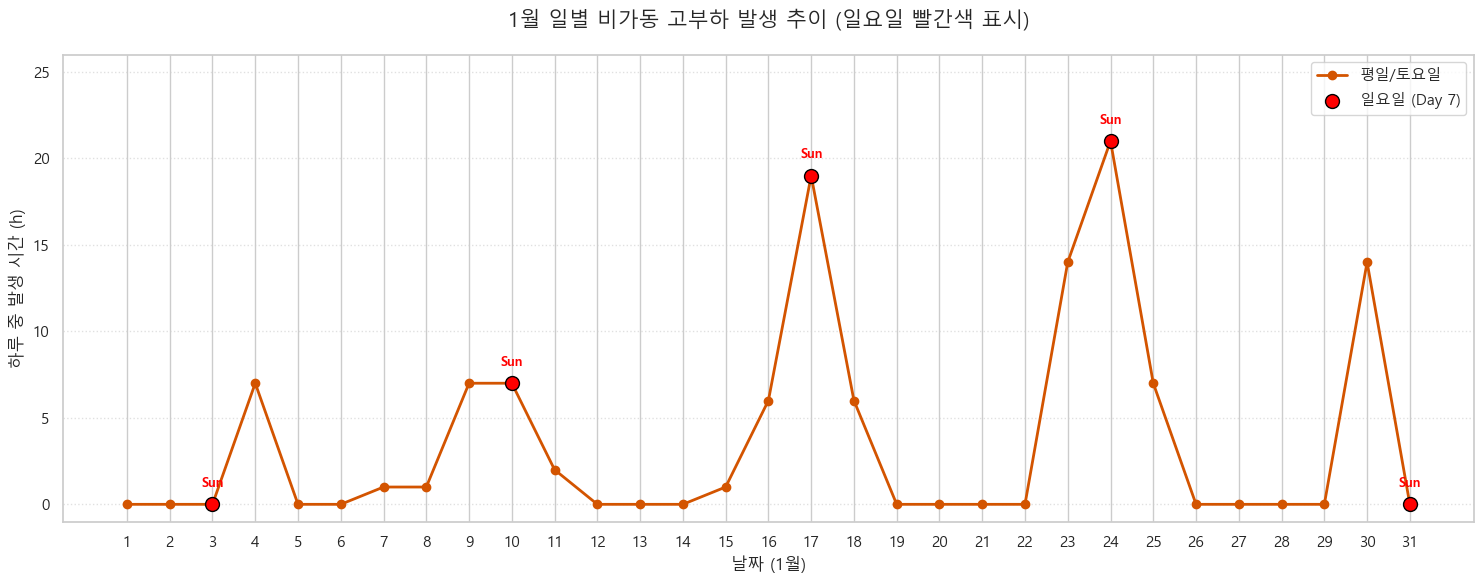

--- 1월 일요일 전력 관리 요약 ---
일요일 평균 발생 건수: 9.40회
일요일 중 최대 발생: 1월 24일 (21회)


In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 1월(m=1) 데이터 필터링 및 기준값 계산
df_jan = power_df[power_df['m'] == 1].copy()
df_zero_jan = df_jan[df_jan['생산량'] == 0].copy()
q3_val = df_zero_jan['평균'].quantile(0.75)

# 2. 일별(d) 3Q 초과 빈도 및 해당 날짜의 요일(day) 정보 추출
# 하루 24개 데이터 중 'day' 값은 동일하므로 first()로 가져옵니다.
daily_data = df_zero_jan.groupby('d').agg({
    '평균': lambda x: (x > q3_val).sum(),
    'day': 'first'
}).reindex(range(1, 32), fill_value=0)

# 3. 시각화
plt.figure(figsize=(15, 6))

# 전체 추이 선 그래프 (기본 오렌지색)
plt.plot(daily_data.index, daily_data['평균'], 
         marker='o', linestyle='-', color='#D35400', 
         linewidth=2, markersize=6, label='평일/토요일')

# 일요일(day=7) 데이터만 필터링하여 빨간색 점으로 덮어쓰기
sun_data = daily_data[daily_data['day'] == 7]
plt.scatter(sun_data.index, sun_data['평균'], 
            color='red', s=100, label='일요일 (Day 7)', zorder=5, edgecolor='black')

# 4. 그래프 디테일 설정
plt.title(f"1월 일별 비가동 고부하 발생 추이 (일요일 빨간색 표시)", fontsize=15, pad=20)
plt.xlabel("날짜 (1월)", fontsize=12)
plt.ylabel("하루 중 발생 시간 (h)", fontsize=12)
plt.ylim(-1, 26)
plt.xticks(range(1, 32))
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 일요일 텍스트 표시 (선택 사항: 그래프가 복잡하면 제외 가능)
for idx, row in sun_data.iterrows():
    plt.text(idx, row['평균'] + 1, 'Sun', ha='center', color='red', fontsize=9, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# 일요일 통계 요약
print(f"--- 1월 일요일 전력 관리 요약 ---")
print(f"일요일 평균 발생 건수: {sun_data['평균'].mean():.2f}회")
print(f"일요일 중 최대 발생: 1월 {sun_data['평균'].idxmax()}일 ({sun_data['평균'].max()}회)")


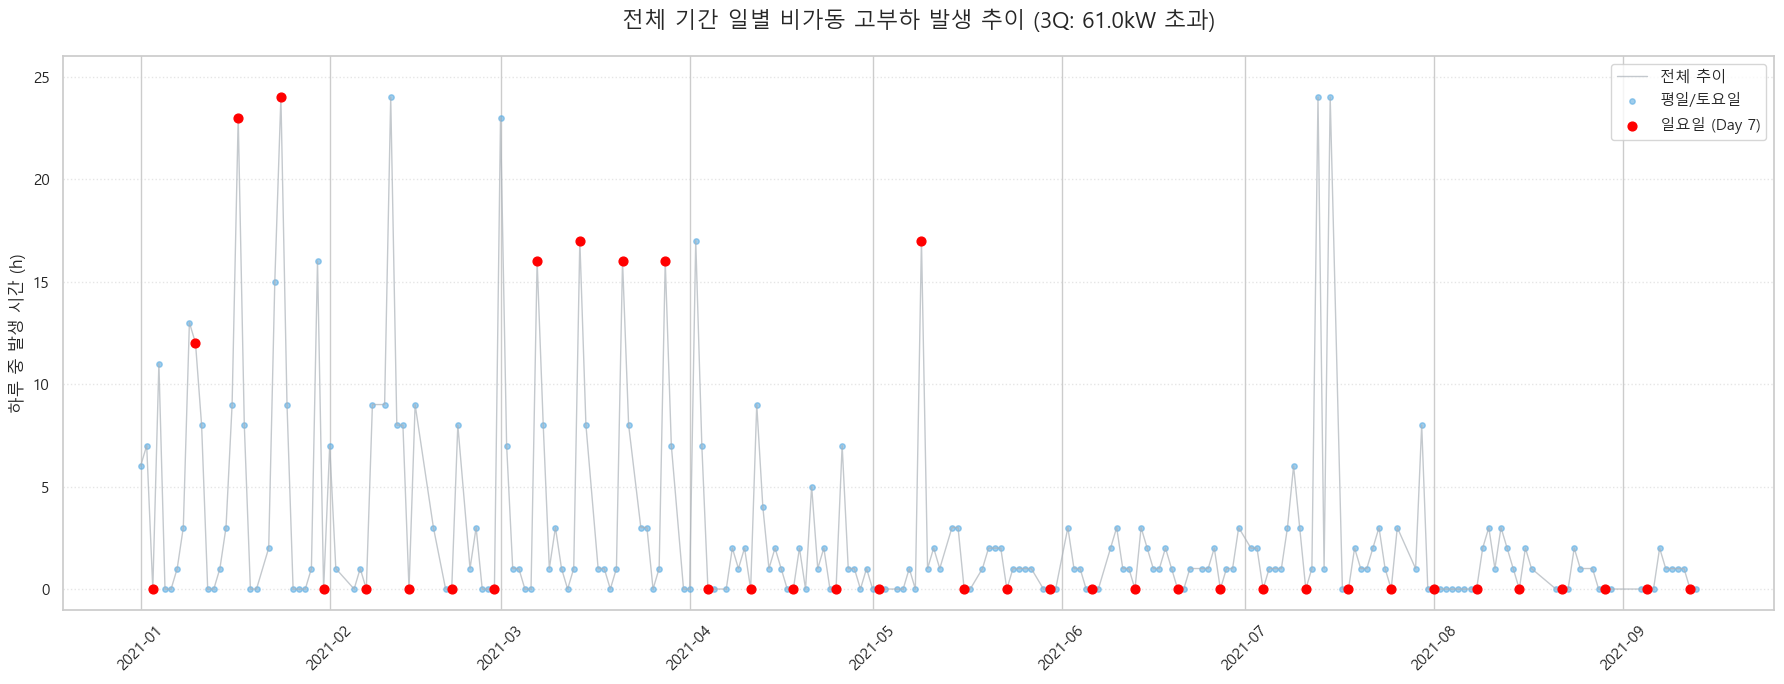

--- 전체 기간 통계 요약 ---
분석 대상 전체 일수: 225일
일요일 평균 발생 시간: 3.81h
평일 평균 발생 시간: 2.76h


In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 전체 데이터에서 비가동(생산량=0) 필터링 및 3Q 기준값 계산
df_zero = power_df[power_df['생산량'] == 0].copy()
q3_val = df_zero['평균'].quantile(0.75)

# 2. '날짜' 형식 재구성 (전체 기간 그룹화를 위해 datetime 객체 생성)
# 기존 '날짜' 컬럼이 20210101 형태의 정수라면 문자열 변환 후 처리
power_df['dt'] = pd.to_datetime(power_df['날짜'].astype(str))

# 3. 일별(dt) 3Q 초과 빈도 및 요일 정보 집계
# 하루 24개 데이터 중 'day'는 동일하므로 first로 가져옵니다.
total_daily = power_df[power_df['생산량'] == 0].groupby('dt').agg({
    '평균': lambda x: (x > q3_val).sum(),
    'day': 'first'
}).sort_index()

# 4. 시각화
plt.figure(figsize=(18, 7))

# 전체 추이 선 (기본 회색/하늘색 계열로 가독성 높임)
plt.plot(total_daily.index, total_daily['평균'], 
         linestyle='-', color='#ABB2B9', linewidth=1, alpha=0.7, label='전체 추이')

# 평일/토요일 점 (작은 점)
plt.scatter(total_daily[total_daily['day'] != 7].index, 
            total_daily[total_daily['day'] != 7]['평균'], 
            color='#5DADE2', s=15, alpha=0.6, label='평일/토요일')

# 일요일(day=7) 점 (큰 빨간 점으로 강조)
sun_df = total_daily[total_daily['day'] == 7]
plt.scatter(sun_df.index, sun_df['평균'], 
            color='red', s=40, label='일요일 (Day 7)', zorder=5)

# 5. 그래프 상세 설정
plt.title(f"전체 기간 일별 비가동 고부하 발생 추이 (3Q: {q3_val:.1f}kW 초과)", fontsize=16, pad=20)
plt.ylabel("하루 중 발생 시간 (h)", fontsize=12)
plt.ylim(-1, 26)

# X축 날짜 포맷 설정 (데이터 양에 따라 1주일~한달 간격 자동 조절)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # 월 단위로 주 눈금
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.show()

# 요약 통계
print(f"--- 전체 기간 통계 요약 ---")
print(f"분석 대상 전체 일수: {len(total_daily)}일")
print(f"일요일 평균 발생 시간: {sun_df['평균'].mean():.2f}h")
print(f"평일 평균 발생 시간: {total_daily[total_daily['day'] != 7]['평균'].mean():.2f}h")


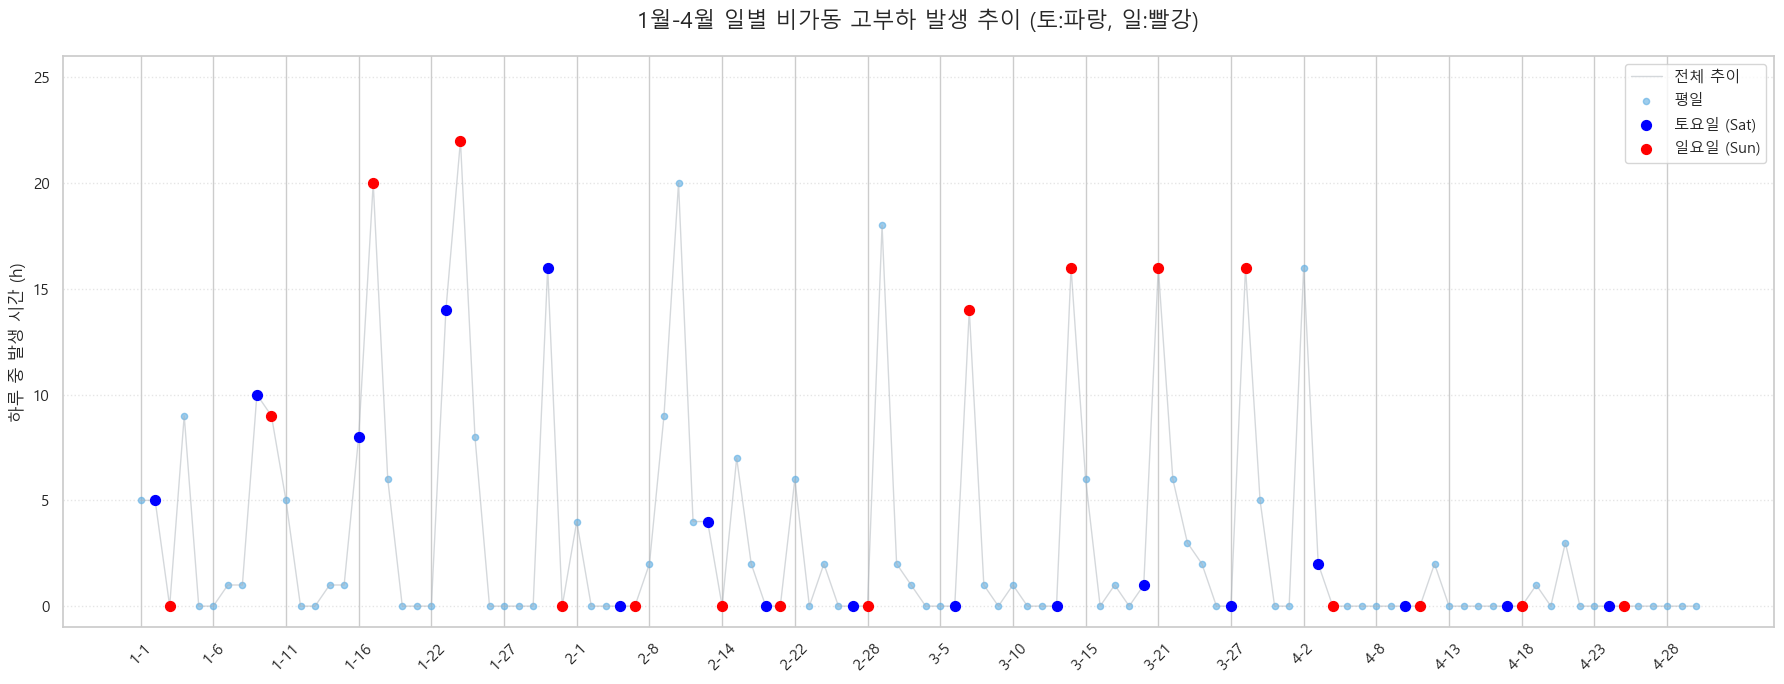

--- 1월~4월 요일별 평균 발생 시간 ---
평일: 2.18h
토요일: 3.53h
일요일: 6.65h


In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 1월~4월(m 1~4) 데이터 필터링 및 비가동(생산량=0) 추출
df_target = power_df[(power_df['m'] >= 1) & (power_df['m'] <= 4)].copy()
df_zero = df_target[df_target['생산량'] == 0].copy()

# 2. 비가동 전력의 3Q 기준값 계산
q3_val = df_zero['평균'].quantile(0.75)

# 3. 일별(m, d 조합) 3Q 초과 빈도 및 요일(day) 정보 집계
# 날짜 순서대로 정렬하기 위해 m과 d를 기준으로 그룹화합니다.
daily_stats = df_zero.groupby(['m', 'd']).agg({
    '평균': lambda x: (x > q3_val).sum(),
    'day': 'first'
}).reset_index()

# 시각화를 위한 X축 레이블 생성 (예: "1-1", "1-2"...)
daily_stats['date_label'] = daily_stats['m'].astype(str) + "-" + daily_stats['d'].astype(str)

# 4. 시각화
plt.figure(figsize=(18, 7))

# 전체 추이 선 그래프
plt.plot(daily_stats.index, daily_stats['평균'], color='#ABB2B9', linewidth=1, alpha=0.5, label='전체 추이')

# 평일(월~금) 점
df_weekday = daily_stats[daily_stats['day'] < 6]
plt.scatter(df_weekday.index, df_weekday['평균'], color='#5DADE2', s=20, alpha=0.6, label='평일')

# 토요일(day=6) 점 - 파란색
df_sat = daily_stats[daily_stats['day'] == 6]
plt.scatter(df_sat.index, df_sat['평균'], color='blue', s=50, label='토요일 (Sat)', zorder=5)

# 일요일(day=7) 점 - 빨간색
df_sun = daily_stats[daily_stats['day'] == 7]
plt.scatter(df_sun.index, df_sun['평균'], color='red', s=50, label='일요일 (Sun)', zorder=5)

# 5. 그래프 설정
plt.title(f"1월-4월 일별 비가동 고부하 발생 추이 (토:파랑, 일:빨강)", fontsize=16, pad=20)
plt.ylabel("하루 중 발생 시간 (h)", fontsize=12)
plt.ylim(-1, 26)

# X축 레이블을 적절한 간격으로 표시 (데이터가 많으므로 5일 간격)
plt.xticks(ticks=range(0, len(daily_stats), 5), 
           labels=daily_stats['date_label'].iloc[::5], rotation=45)

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.show()

print(f"--- 1월~4월 요일별 평균 발생 시간 ---")
print(f"평일: {df_weekday['평균'].mean():.2f}h")
print(f"토요일: {df_sat['평균'].mean():.2f}h")
print(f"일요일: {df_sun['평균'].mean():.2f}h")


In [88]:
power_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        6168 non-null   datetime64[ns]
 1   시간        6168 non-null   int64         
 2   15분       6168 non-null   int64         
 3   30분       6168 non-null   int64         
 4   45분       6168 non-null   int64         
 5   60분       6168 non-null   int64         
 6   평균        6168 non-null   int64         
 7   생산량       6168 non-null   int64         
 8   기온        6168 non-null   float64       
 9   풍속        6165 non-null   float64       
 10  습도        6168 non-null   int64         
 11  강수량       6168 non-null   float64       
 12  전기요금(계절)  6168 non-null   float64       
 13  day       6168 non-null   int64         
 14  d         6168 non-null   int64         
 15  m         6168 non-null   int64         
 16  공장인원      6168 non-null   float64       
 17  인건비       6168 non-null  

In [ ]:
# 생산량이 0 인 경우의 최대전력량 분포
df = power_df[power_df['생산량']==0]['평균']


## 2.5 데이터 전처리 : 변수 타입 변경 및 파생 변수 추가

### 일자-시간 변수 추가 - Index로 추가

In [109]:
# import datetime

# 1. datehour 컬럼 생성 (문자열로 치환 -> 결합 -> 포맷을 지정하여 datatime 으로 변환)
power_df['datehour'] = pd.to_datetime(
    power_df['날짜'].astype(str) + power_df['시간'].astype(str).str.zfill(2),
    format='%Y%m%d%H'
)

# 2. datetime 컬럼을 인덱스로 설정
# inplace=True를 사용하면 원본 df가 바로 수정됩니다.
power_df = power_df.set_index('datehour', drop=True) # 기존 인데스는 제거(Drop)

power_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,dt
datehour,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01
2021-01-01 01:00:00,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01
2021-01-01 02:00:00,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01
2021-01-01 03:00:00,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01
2021-01-01 04:00:00,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5,2021-09-14
2021-09-14 20:00:00,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5,2021-09-14
2021-09-14 21:00:00,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5,2021-09-14


## 열외 - 전력량 사용량 시각화

### 일자-시간 별 전력 Peak 값 변경 - int54 -> float

In [140]:
peak_df = power_df[['15분',	'30분',	'45분',	'60분',	'평균'	]].astype(float)
peak_df

,15분,30분,45분,60분,평균
datehour,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107.0
...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153.0
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128.0
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128.0


### 평균값 다시 계산

In [141]:
peak_df['평균'] = power_df[['15분',	'30분',	'45분',	'60분']].mean(axis=1)
peak_df

,15분,30분,45분,60분,평균
datehour,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61.25
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,104.50
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,103.75
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105.25
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,106.75
...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153.25
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128.00
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128.25


### 전력 Peak 사용량 시각화

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# 최신 버전 권장 설정 (sns.set 대신 sns.set_theme 사용)
sns.set_theme(
    style="whitegrid",             # 배경 테마 (darkgrid, white, ticks 등 선택 가능)
    rc={
        "figure.figsize": (20, 10),
        "font.family": "Malgun Gothic",  # 윈도우용 맑은 고딕
        "axes.unicode_minus": False      # 마이너스 기호 깨짐 방지
    }
)


* 2021년 전체

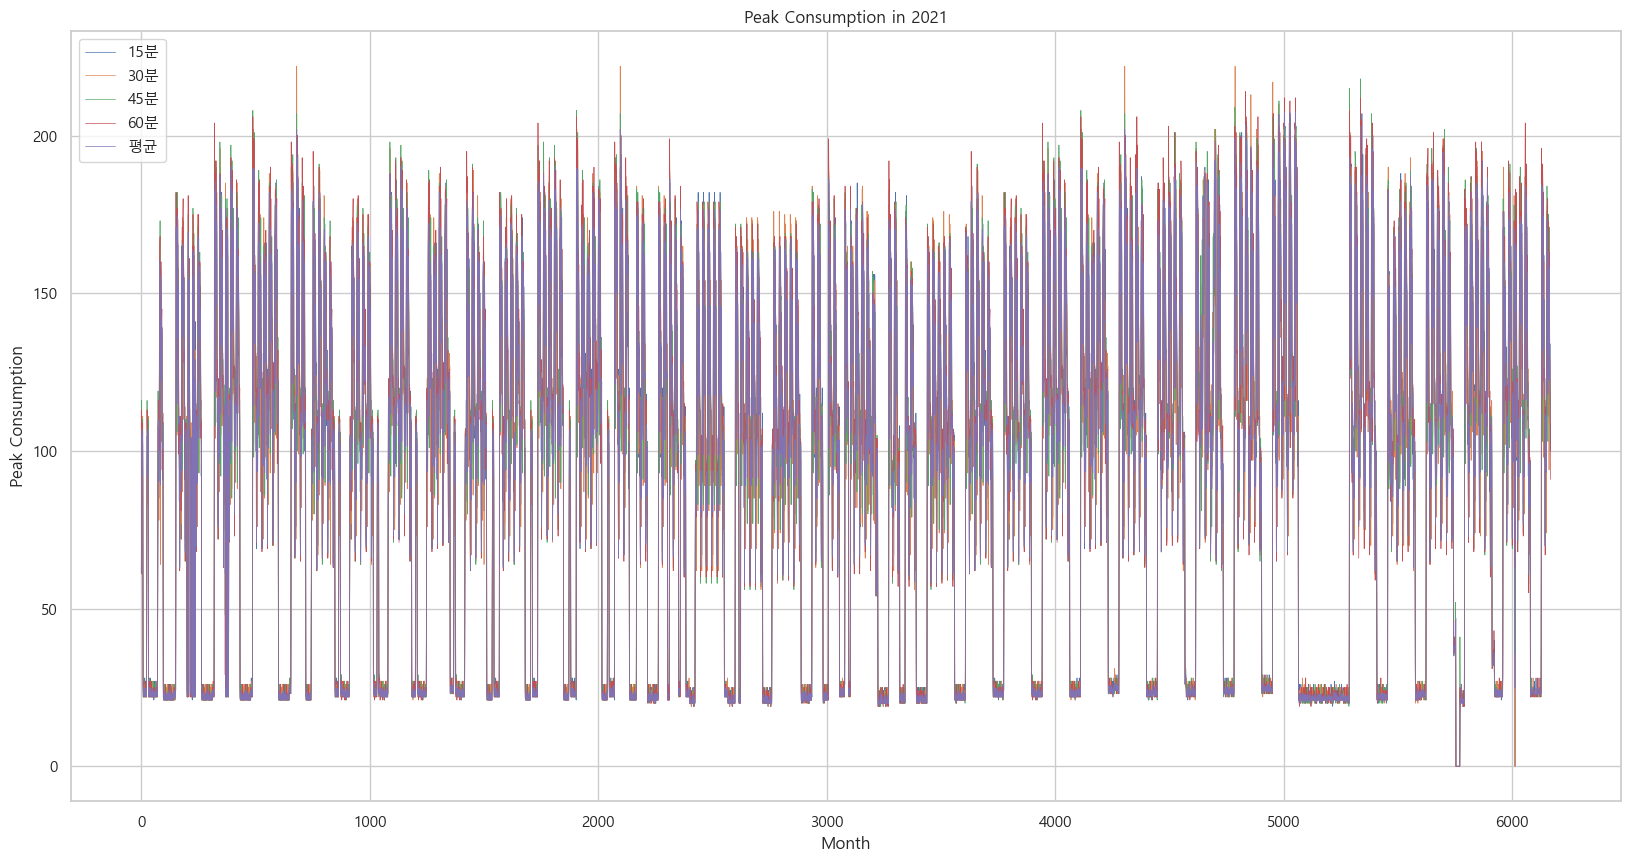

In [134]:
peak_df.plot(linewidth = 0.5);
plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

In [143]:
off_df = power_df[(power_df['생산량']==0) & (power_df['평균']<30)& (power_df['day']<6) & (power_df['시간']==10)]
off_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,생산구분
datehour,,,,,,,,,,,,,,,,,,,
2021-01-01 10:00:00,20210101,10,22,22,22,22,22,0,-1.2,2.1,54,0.0,109.8,5,1,1,0.0,1.0,-1
2021-01-05 10:00:00,20210105,10,21,21,22,26,23,0,4.1,2.0,64,0.0,109.8,2,5,1,0.0,1.0,-1
2021-01-06 10:00:00,20210106,10,21,21,22,26,23,0,-4.7,3.5,45,0.0,109.8,3,6,1,0.0,1.0,-1
2021-01-12 10:00:00,20210112,10,21,21,22,26,23,0,-0.3,1.5,53,0.0,109.8,2,12,1,0.0,1.0,-1
2021-01-13 10:00:00,20210113,10,21,21,22,26,23,0,4.6,0.3,52,0.0,109.8,3,13,1,0.0,1.0,-1
2021-01-19 10:00:00,20210119,10,21,21,22,26,23,0,-3.1,2.1,43,0.0,109.8,2,19,1,0.0,1.0,-1
2021-01-20 10:00:00,20210120,10,21,21,22,26,23,0,3.8,1.3,28,0.0,109.8,3,20,1,0.0,1.0,-1
2021-01-26 10:00:00,20210126,10,21,21,22,26,23,0,7.2,1.6,98,3.0,109.8,2,26,1,0.0,1.0,-1
2021-01-27 10:00:00,20210127,10,21,21,22,26,23,0,5.5,3.1,58,0.0,109.8,3,27,1,0.0,1.0,-1


* 2021년 8월 통계

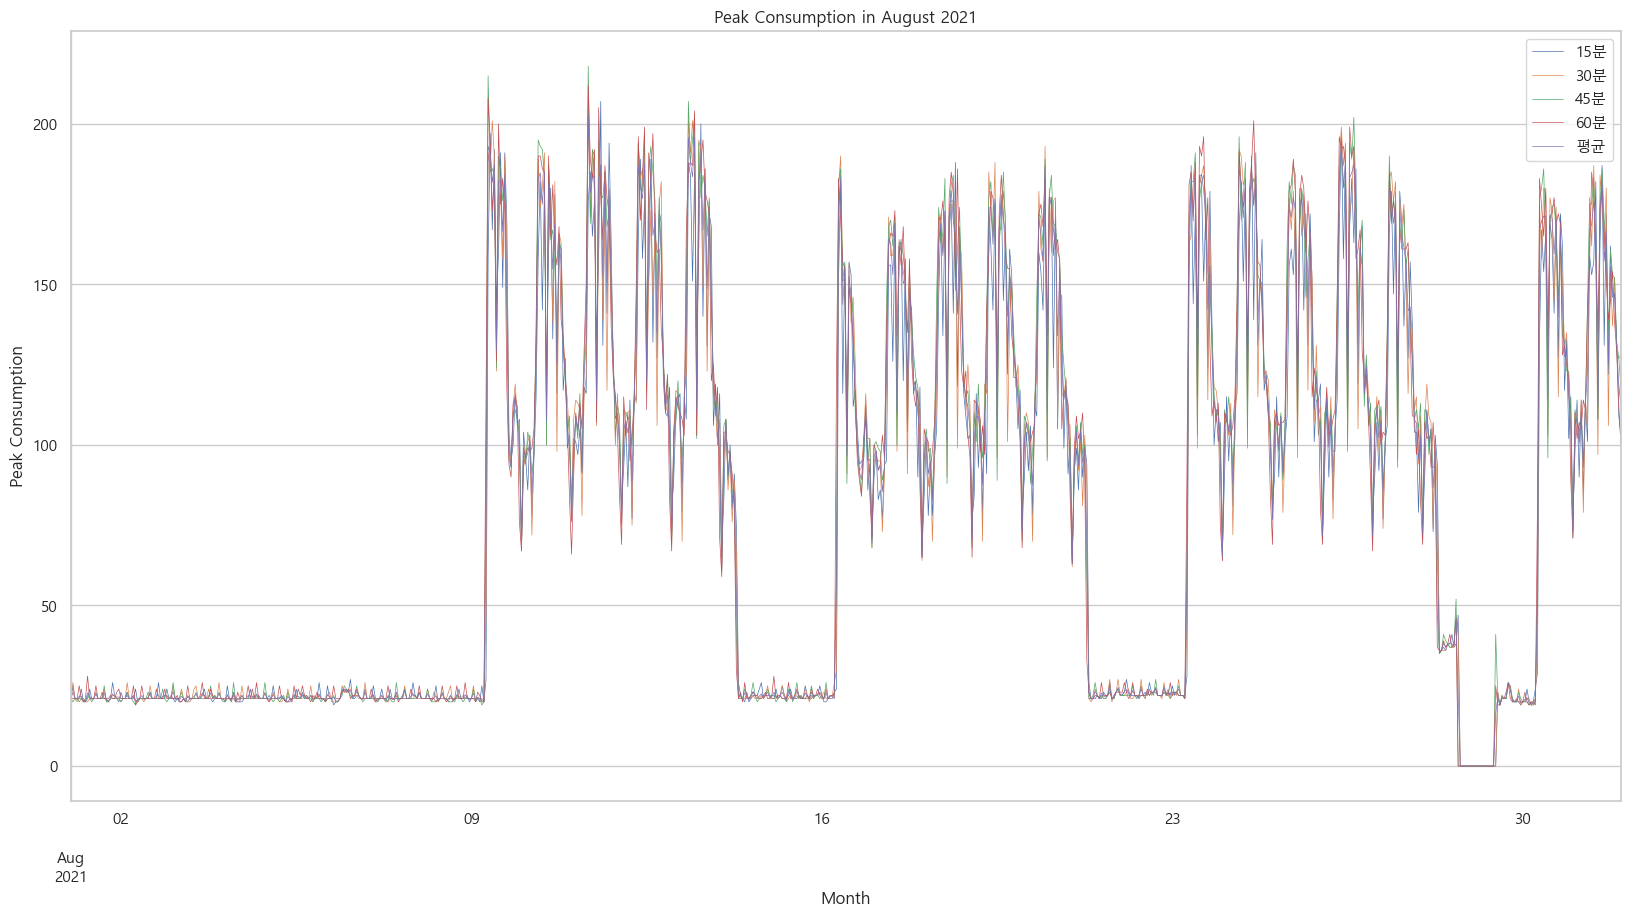

In [144]:
peak_df.loc['2021-08'].plot(linewidth = 0.5);
plt.title("Peak Consumption in August 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

** 8월 첫주 공장 휴가로 추정

* 2021년 1월 1일 추이

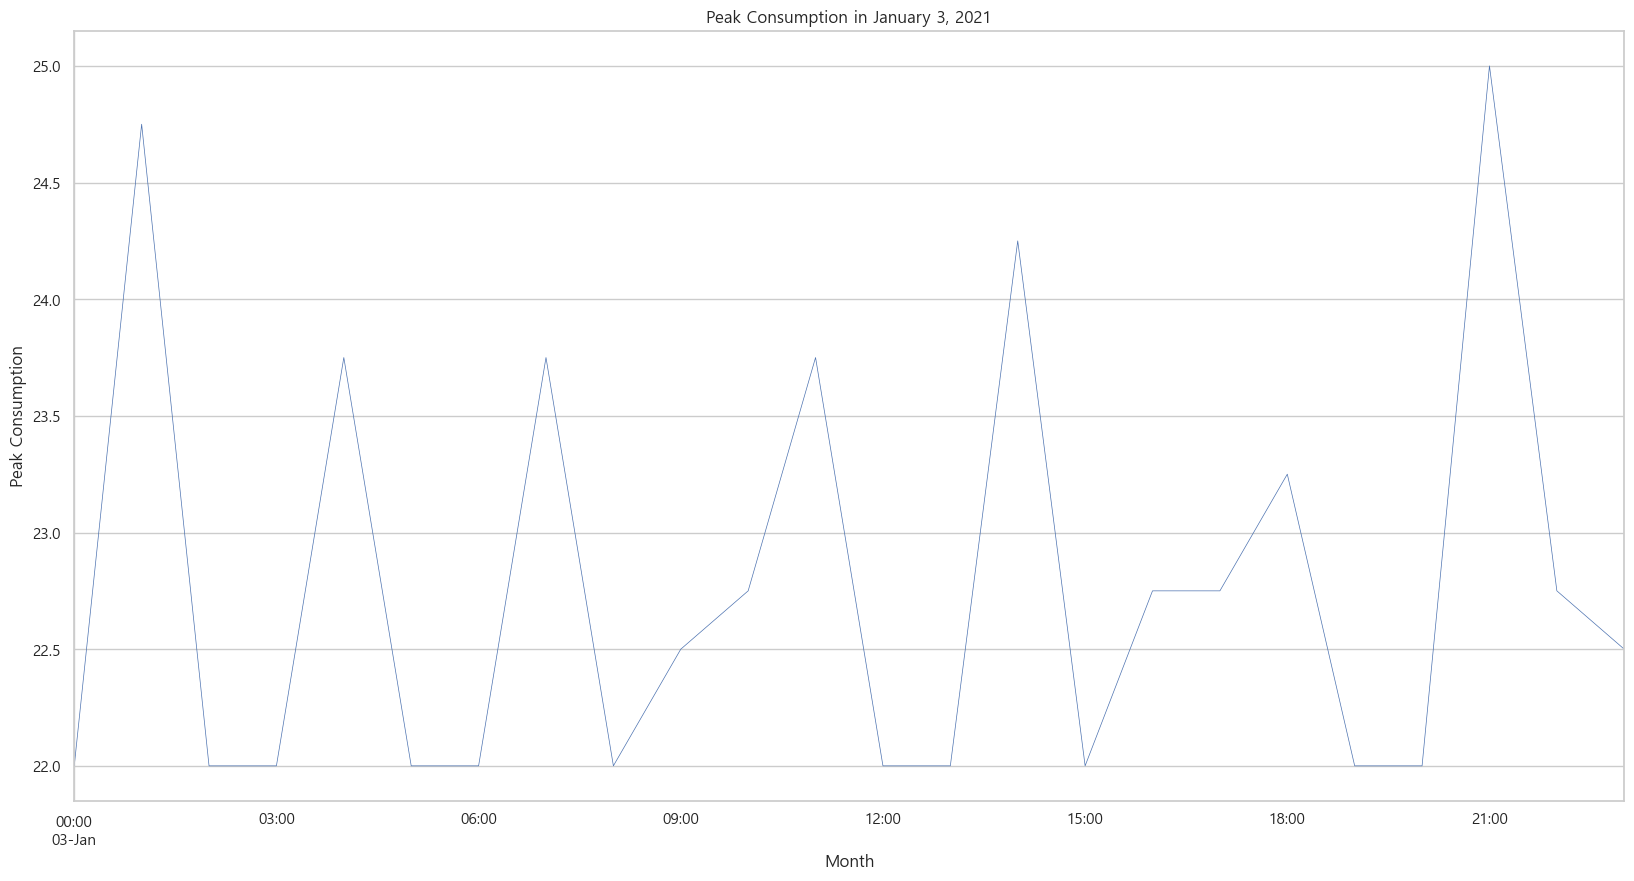

In [145]:
# peak_df.loc['2021-01-01'].plot(linewidth = 0.5)
peak_df.loc['2021-01-03']['평균'].plot(linewidth = 0.5)
plt.title("Peak Consumption in January 3, 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

## (끝) 열외 - 전력량 사용량 시각화 

## 파생변수 추가 - 주말 및 공휴일

In [110]:
from datetime import datetime

datetime.strptime('2021-01-01', '%Y-%m-%d').weekday()  # 월요일 부터 0으로 시작 - 일요일 6

datetime.now().isoweekday()  # 월요일 부터 1으로 시작 - 일요일 7

3

In [111]:
# 주말 추가 : 토, 일 - 통상 휴무일
power_df['weekend'] = np.where(power_df['day'] > 5, 1, 0)

# 법정 공휴일 및 하계휴가일
holidays = ["2021-01-01", "2021-02-11", "2021-02-12","2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]  # 9월 이후 데이터는 생략 
holidays += ["2021-08-02", "2021-08-03", "2021-08-04","2021-08-05"]  # 공장 휴뮤일 추가

# 인덱스의 날짜 부분만 문자열로 바꿔서 리스트와 비교
power_df['holiday'] = power_df.index.strftime('%Y-%m-%d').isin(holidays).astype(int)

power_df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,...,강수량,전기요금(계절),day,d,m,공장인원,인건비,dt,weekend,holiday
datehour,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61,0,-3.2,2.4,...,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1
2021-01-01 01:00:00,20210101,1,96,93,116,113,105,0,-4.5,1.5,...,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1
2021-01-01 02:00:00,20210101,2,106,96,106,107,104,0,-3.9,2.6,...,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1
2021-01-01 03:00:00,20210101,3,92,110,110,109,105,0,-4.1,2.6,...,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1
2021-01-01 04:00:00,20210101,4,108,105,106,108,107,0,-4.6,2.6,...,0.0,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,20210914,19,152,151,171,139,153,1497,21.7,3.6,...,9.4,167.2,2,14,9,2.442088,1.5,2021-09-14,0,0
2021-09-14 20:00:00,20210914,20,124,130,128,130,128,45,22.2,4.2,...,9.4,167.2,2,14,9,0.087891,1.5,2021-09-14,0,0
2021-09-14 21:00:00,20210914,21,134,130,125,124,128,149,22.2,4.3,...,9.4,167.2,2,14,9,0.290448,1.5,2021-09-14,0,0


## 파생변수 추가 - 생산구분

In [112]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture

# 1. 데이터 분리 및 분석용 기울기 계산
mask_zero = power_df['생산량'] <= 0
df_na = power_df[mask_zero].copy()
df_na['생산구분'] = -1

df_target = power_df[~mask_zero].copy()
# '생산인력비율' 계산 (제품 100개당 투입 인원)
df_target['생산인력비율'] = df_target['공장인원'] / (df_target['생산량'] / 100)

# 2. GMM 분류 및 초기 라벨링 (4, 2, 1)
X_ratio = df_target[['생산인력비율']].values
gmm = GaussianMixture(n_components=3, n_init=20, random_state=42)
df_target['cluster'] = gmm.fit_predict(X_ratio)

# 평균 기울기가 높은 순서대로 4, 2, 1 매핑
cluster_avg = df_target.groupby('cluster')['생산인력비율'].mean().sort_values(ascending=False)
label_map = {cluster_avg.index[0]: 4, cluster_avg.index[1]: 2, cluster_avg.index[2]: 1}
df_target['생산구분'] = df_target['cluster'].map(label_map)

# 3. [정밀 재분류] 중간(2) 그룹의 75% 지점 * 1.1 적용
middle_q3 = df_target.loc[df_target['생산구분'] == 2, '생산인력비율'].quantile(0.75)
threshold = middle_q3 * 1.15
reassign_mask = (df_target['생산구분'] == 2) & (df_target['생산인력비율'] <= threshold)
df_target.loc[reassign_mask, '생산구분'] = 1

# 4. 결과 통합 및 데이터프레임 정리
# (1) power_df: 기존 모든 컬럼 유지 + '생산구분'만 추가
# 모든 행의 라벨을 하나로 합친 뒤, 원본 power_df에 인덱스 기준으로 붙입니다.
all_labels = pd.concat([df_target[['생산구분']], df_na[['생산구분']]]).sort_index()
power_df['생산구분'] = all_labels['생산구분']

# (2) product_df: 요청하신 5개 컬럼만 추출
product_df = df_target[['생산량', '공장인원', '생산인력비율', 'cluster', '생산구분', '평균']].copy()

print("분류 및 데이터 통합 완료!")
print(f"power_df 컬럼 목록: {power_df.columns.tolist()}")
print(f"product_df 컬럼 목록: {product_df.columns.tolist()}")


분류 및 데이터 통합 완료!
power_df 컬럼 목록: ['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비', 'dt', 'weekend', 'holiday', '생산구분']
product_df 컬럼 목록: ['생산량', '공장인원', '생산인력비율', 'cluster', '생산구분', '평균']


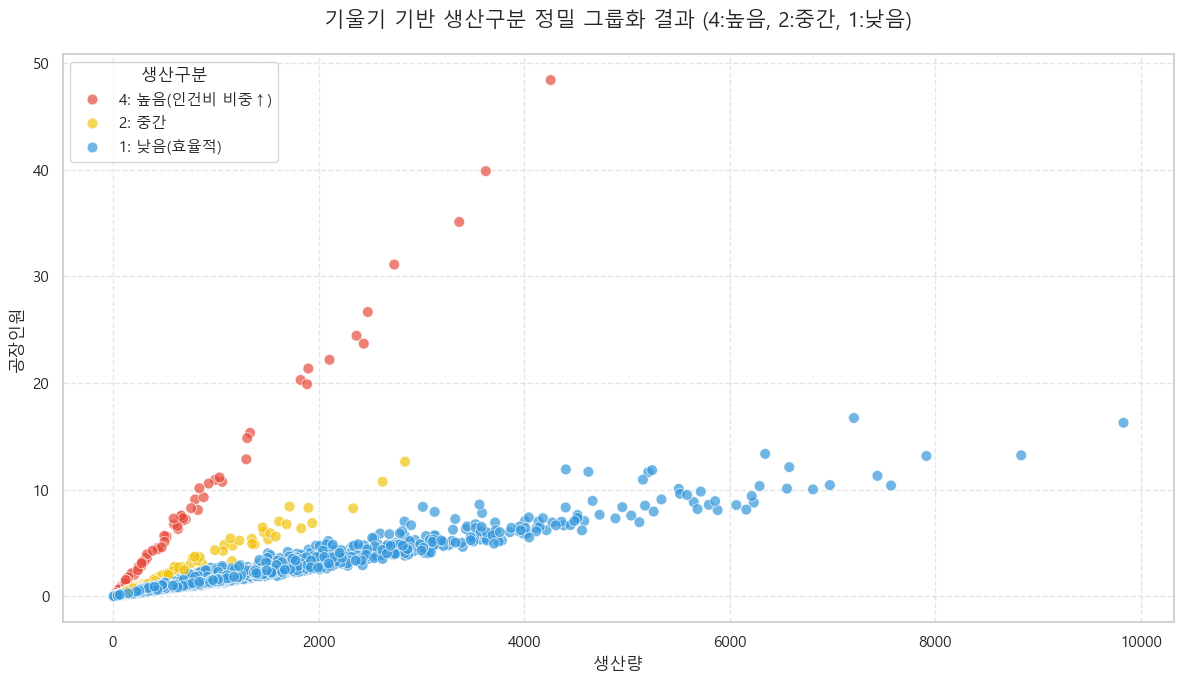

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화용 데이터 준비 (N/A인 -1 제외)
plot_df = power_df[power_df['생산구분'] != -1].copy()

# 2. 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 3. 산점도 시각화
plt.figure(figsize=(12, 7))

# 숫자 라벨에 따른 색상 및 순서 지정 (4:높음, 2:중간, 1:낮음)
palette = {4: '#e74c3c', 2: '#f1c40f', 1: '#3498db'}
hue_order = [4, 2, 1]

sns.scatterplot(
    data=plot_df, 
    x='생산량', 
    y='공장인원', 
    hue='생산구분', 
    hue_order=hue_order,
    palette=palette,
    alpha=0.7,
    edgecolor='w',
    s=60
)

# 4. 그래프 꾸미기 (범례 텍스트 커스텀)
plt.title('기울기 기반 생산구분 정밀 그룹화 결과 (4:높음, 2:중간, 1:낮음)', fontsize=15, pad=20)
plt.xlabel('생산량', fontsize=12)
plt.ylabel('공장인원', fontsize=12)

# 범례에 숫자와 의미를 명시적으로 표시
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['4: 높음(인건비 비중↑)', '2: 중간', '1: 낮음(효율적)'], 
           title='생산구분', loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



## 중복 또는 여분(Redundant) 속성 삭제
- 날짜, 평균

In [114]:
power_df = power_df.drop(columns=['날짜'], errors='ignore')
power_df

,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,...,전기요금(계절),day,d,m,공장인원,인건비,dt,weekend,holiday,생산구분
datehour,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,0,62,61,61,61,61,0,-3.2,2.4,71,...,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1,-1
2021-01-01 01:00:00,1,96,93,116,113,105,0,-4.5,1.5,77,...,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1,-1
2021-01-01 02:00:00,2,106,96,106,107,104,0,-3.9,2.6,58,...,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1,-1
2021-01-01 03:00:00,3,92,110,110,109,105,0,-4.1,2.6,56,...,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1,-1
2021-01-01 04:00:00,4,108,105,106,108,107,0,-4.6,2.6,60,...,109.8,5,1,1,0.000000,1.5,2021-01-01,0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,19,152,151,171,139,153,1497,21.7,3.6,85,...,167.2,2,14,9,2.442088,1.5,2021-09-14,0,0,1
2021-09-14 20:00:00,20,124,130,128,130,128,45,22.2,4.2,78,...,167.2,2,14,9,0.087891,1.5,2021-09-14,0,0,1
2021-09-14 21:00:00,21,134,130,125,124,128,149,22.2,4.3,76,...,167.2,2,14,9,0.290448,1.5,2021-09-14,0,0,1


In [214]:
power_df.corr()

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비,생산구분,weekend,holiday
시간,1.000000e+00,0.124191,0.112568,0.101041,0.076296,0.132111,0.109343,0.097169,-0.145032,0.122523,1.083940e-15,-5.182983e-18,3.872564e-18,1.634985e-15,0.084077,-0.166807,-0.011943,-5.053555e-19,9.044081e-17
15분,1.241908e-01,1.000000,0.980295,0.966859,0.950034,0.520424,0.050760,0.115016,-0.085205,-0.008241,5.588134e-02,-4.283119e-01,5.255441e-02,3.360101e-02,0.295909,-0.202557,0.564976,-5.138289e-01,-1.357573e-01
30분,1.125677e-01,0.980295,1.000000,0.982443,0.959004,0.515841,0.049524,0.113965,-0.084102,-0.010410,5.620322e-02,-4.266740e-01,5.575440e-02,3.267924e-02,0.288622,-0.195760,0.558095,-5.111349e-01,-1.352719e-01
45분,1.010415e-01,0.966859,0.982443,1.000000,0.984789,0.513789,0.052818,0.115627,-0.082522,-0.013136,5.904420e-02,-4.329573e-01,5.604744e-02,3.520298e-02,0.286091,-0.211635,0.560550,-5.208535e-01,-1.375502e-01
60분,7.629631e-02,0.950034,0.959004,0.984789,1.000000,0.499723,0.055651,0.128467,-0.090875,-0.014812,5.787812e-02,-4.375765e-01,5.635399e-02,3.415260e-02,0.276778,-0.243434,0.555452,-5.242898e-01,-1.385533e-01
생산량,1.321111e-01,0.520424,0.515841,0.513789,0.499723,1.000000,0.117780,0.115388,-0.109503,0.008171,6.892961e-02,-2.591290e-01,4.483612e-02,6.897566e-02,0.785115,-0.280625,0.418957,-3.172421e-01,-1.008455e-01
기온,1.093433e-01,0.050760,0.049524,0.052818,0.055651,0.117780,1.000000,-0.192028,0.401553,0.118524,8.098254e-01,1.012953e-02,1.084866e-01,8.574903e-01,0.030540,-0.184611,0.006793,2.444836e-02,5.594888e-02
풍속,9.716902e-02,0.115016,0.113965,0.115627,0.128467,0.115388,-0.192028,1.000000,-0.439745,0.049009,-2.541913e-01,3.896542e-03,-1.190186e-02,-2.669439e-01,0.088701,-0.349769,0.013203,2.863693e-02,-5.210327e-02
습도,-1.450321e-01,-0.085205,-0.084102,-0.082522,-0.090875,-0.109503,0.401553,-0.439745,1.000000,0.219997,5.255203e-01,5.281977e-02,-2.305278e-02,5.485028e-01,-0.121135,0.308435,-0.030778,3.238296e-02,3.434412e-02
강수량,1.225228e-01,-0.008241,-0.010410,-0.013136,-0.014812,0.008171,0.118524,0.049009,0.219997,1.000000,1.393468e-01,-7.520445e-03,-3.569401e-02,1.618289e-01,-0.004847,-0.012680,-0.024937,3.168007e-02,-5.015457e-03


In [ ]:
aa = power_df[power_df['생산구분']==2]['평균']
aa.min(), aa.max()

(np.int64(50), np.int64(88))

In [156]:
aa = power_df[power_df['생산구분']==2]['생산량']
aa.min(), aa.max()

(np.int64(1), np.int64(2841))

### 전력량 - 추정값

In [171]:
import pandas as pd
import numpy as np

# --- 1. 분석용 상수 설정 ---
MAX_PRODUCTION_1 = 10000  # ppower_df[power_df['생산구분']==1]['생산량'].max()
MAX_POWER_1 = 150         # 그룹 1 (고전력) 최고 전력사용량
BASE_LOAD_1 = 75        # 그룹 1 (고전력) 최저 전력사용량

MAX_PRODUCTION_2 = 3000  # power_df[power_df['생산구분']==2]['생산량'].max()
MAX_POWER_2 = 75        # 그룹 2 (중전력) 최고 전력사용량
BASE_LOAD_2 = 40        # 그룹 2 (중전력) 최저 전력사용량


# --- 2. 비가동 데이터(생산량 0) 기반 기준 통계량 자동 산출 ---
# '평균' 컬럼은 측정된 최대전력 평균값입니다.
df_zero_ref = power_df[power_df['생산량'] == 0]['평균']

# 최빈값 (안전하게 첫 번째 값 추출)
mode_val = df_zero_ref.mode().iloc[0] if not df_zero_ref.mode().empty else df_zero_ref.median()

mean_val = df_zero_ref.mean()
# 3Q (상위 25% 지점)
q3_val = df_zero_ref.quantile(0.75)
# 위험군 기준 (4 * 최빈값)
high_val = 4 * mode_val

print(f"[설정 확인] 생산기준 #1 - 최대생산 : {MAX_PRODUCTION_1}, 피크:{MAX_POWER_1}")
print(f"[설정 확인] 생산기준 #2 - 최대생산 : {MAX_PRODUCTION_2}, 피크:{MAX_POWER_2}")
print(f"[통계 확인] 최빈:{mode_val:.1f}, 3Q:{q3_val:.1f}, 위험기준:{high_val:.1f}")

# --- 3. 사용전력량 산정 함수 정의 ---
def calculate_kwh_final(row):
    peak = row['평균']        # 최대전력 평균 (kW)
    prod = row['생산량']      # 생산량
    cat = row['생산구분']      # GMM 분류 (-1, 1, 2, 4)
    
    # 공통 기저 부하 (비가동 최빈값 사용)
    base_load_zero = mode_val * 0.8
    
    # 이상치 조정
    if ( peak < base_load_zero ) : peak = base_load_zero
    
    # [Case A] 비가동 상태 (생산구분 -1 또는 생산량 0)
    if cat == -1 or prod <= 0:
        
        if peak <= mean_val:
            result_estimate = base_load_zero
        elif peak <= q3_val:      # 일반 대기
            result_estimate = base_load_zero * 1.2
        elif peak <= high_val:    # 주의 구간 (3Q ~ 4*Mode)
            result_estimate = base_load_zero + (peak - base_load_zero) * 0.3
        else:  # 위험 구간 (4*Mode 초과)
            result_estimate = base_load_zero + (high_val - base_load_zero) * 0.3 
            result_estimate = result_estimate + (peak - high_val) * 0.6

    # [Case B] 가동 상태 (제품 그룹별 산식)
    elif cat == 1:
        
        base_load_1 = BASE_LOAD_1
        # 그룹 1: 고전력 (기울기 동적 계산)
        slope = (MAX_POWER_1 - base_load_1) / MAX_PRODUCTION_1
        result_estimate = base_load_1 + (prod * slope)
        
    elif cat == 2:
        
        base_load_2 = BASE_LOAD_2
        # 그룹 2: 중전력 (기울기 동적 계산)
        slope = (MAX_POWER_2 - base_load_2) / MAX_PRODUCTION_2
        result_estimate = base_load_2 + (prod * slope)
        
    elif cat == 4:
        # 그룹 4: 저전력 (기저부하 + 최소 가동 가산 = 0 )
        result_estimate = base_load_zero 
    
    else:
        result_estimate = base_load_zero
    
    # 해당 피크의 90% 이내로 조정
    result_estimate = min(result_estimate, peak*0.95)
    # 소수점 둘째 자리에서 반올림 (결과 예: 23.46)
    return round(result_estimate, 2)


# --- 4. 데이터프레임 적용 ---
power_df['사용전력량(KWh)'] = power_df.apply(calculate_kwh_final, axis=1)

# 결과 확인
print("\n--- 최종 산정 결과 샘플 ---")
print(power_df[['생산량', '생산구분', '평균', '사용전력량(KWh)']].head(10))

# 일일 합산 데이터 생성 (검증용)
daily_kwh = power_df.groupby(['m', 'd'])['사용전력량(KWh)'].sum()
print(f"\n평균 일일 사용전력량: {daily_kwh.mean():,.2f} KWh")


[설정 확인] 생산기준 #1 - 최대생산 : 10000, 피크:150
[설정 확인] 생산기준 #2 - 최대생산 : 3000, 피크:75
[통계 확인] 최빈:23.0, 3Q:61.0, 위험기준:92.0

--- 최종 산정 결과 샘플 ---
                     생산량  생산구분   평균  사용전력량(KWh)
datehour                                       
2021-01-01 00:00:00    0    -1   61       22.08
2021-01-01 01:00:00    0    -1  105       48.28
2021-01-01 02:00:00    0    -1  104       47.68
2021-01-01 03:00:00    0    -1  105       48.28
2021-01-01 04:00:00    0    -1  107       49.48
2021-01-01 05:00:00    0    -1   92       40.48
2021-01-01 06:00:00    0    -1  107       49.48
2021-01-01 07:00:00    0    -1   61       22.08
2021-01-01 08:00:00    0    -1   24       18.40
2021-01-01 09:00:00    0    -1   22       18.40

평균 일일 사용전력량: 1,349.63 KWh


In [146]:
power_df[['생산량', '생산구분', '평균', '사용전력량(KWh)']]

,생산량,생산구분,평균,사용전력량(KWh)
datehour,,,,
2021-01-01 00:00:00,0,-1,61,23.00
2021-01-01 01:00:00,0,-1,105,64.00
2021-01-01 02:00:00,0,-1,104,63.50
2021-01-01 03:00:00,0,-1,105,64.00
2021-01-01 04:00:00,0,-1,107,65.00
...,...,...,...,...
2021-09-14 19:00:00,1497,1,153,85.10
2021-09-14 20:00:00,45,1,128,75.30
2021-09-14 21:00:00,149,1,128,76.01


In [135]:
power_df[power_df['생산구분'] == 1]['평균'].min()

np.int64(88)

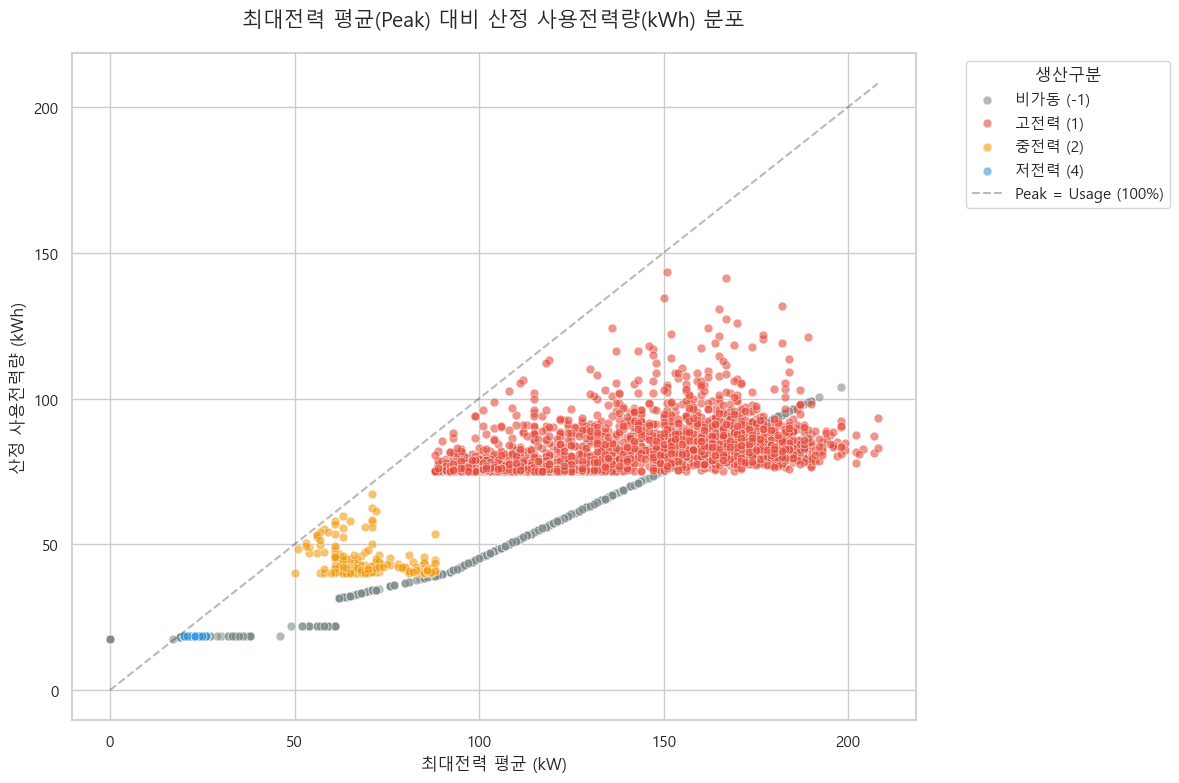

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 설정
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 1. 그래프 크기와 폰트 설정 (최신 방식)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 2. 생산구분별 색상 및 라벨 지정
# -1: 비가동(Gray), 1: 고전력(Red), 2: 중전력(Orange), 4: 저전력(Blue)
palette = {-1: '#7F8C8D', 1: '#E74C3C', 2: '#F39C12', 4: '#3498DB'}
labels = {-1: '비가동 (-1)', 1: '고전력 (1)', 2: '중전력 (2)', 4: '저전력 (4)'}

# 3. 그룹별 산점도 그리기
for cat in sorted(power_df['생산구분'].unique()):
    subset = power_df[power_df['생산구분'] == cat]
    plt.scatter(
        subset['평균'], 
        subset['사용전력량(KWh)'],
        label=labels.get(cat, f'Group {cat}'),
        color=palette.get(cat, 'black'),
        alpha=0.6, 
        s=40, 
        edgecolor='w',
        linewidth=0.5
    )

# 4. 가이드라인 추가 (y=x 선: 피크가 곧 사용량인 100% 지점)
max_val = max(power_df['평균'].max(), power_df['사용전력량(KWh)'].max())
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Peak = Usage (100%)')

# 5. 그래프 디테일
plt.title('최대전력 평균(Peak) 대비 산정 사용전력량(kWh) 분포', fontsize=15, pad=20)
plt.xlabel('최대전력 평균 (kW)', fontsize=12)
plt.ylabel('산정 사용전력량 (kWh)', fontsize=12)
plt.legend(title='생산구분', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# 3. 데이터 분석 - Random Forest

In [149]:
power_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6168 entries, 2021-01-01 00:00:00 to 2021-09-14 23:00:00
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   시간        6168 non-null   int64  
 1   15분       6168 non-null   int64  
 2   30분       6168 non-null   int64  
 3   45분       6168 non-null   int64  
 4   60분       6168 non-null   int64  
 5   생산량       6168 non-null   int64  
 6   기온        6168 non-null   float64
 7   풍속        6165 non-null   float64
 8   습도        6168 non-null   int64  
 9   강수량       6168 non-null   float64
 10  전기요금(계절)  6168 non-null   float64
 11  day       6168 non-null   int64  
 12  d         6168 non-null   int64  
 13  m         6168 non-null   int64  
 14  공장인원      6168 non-null   float64
 15  인건비       6168 non-null   float64
 16  생산구분      6168 non-null   int64  
 17  weekend   6168 non-null   int64  
 18  holiday   6168 non-null   int64  
dtypes: float64(6), int64(13)
memory usage: 963.8

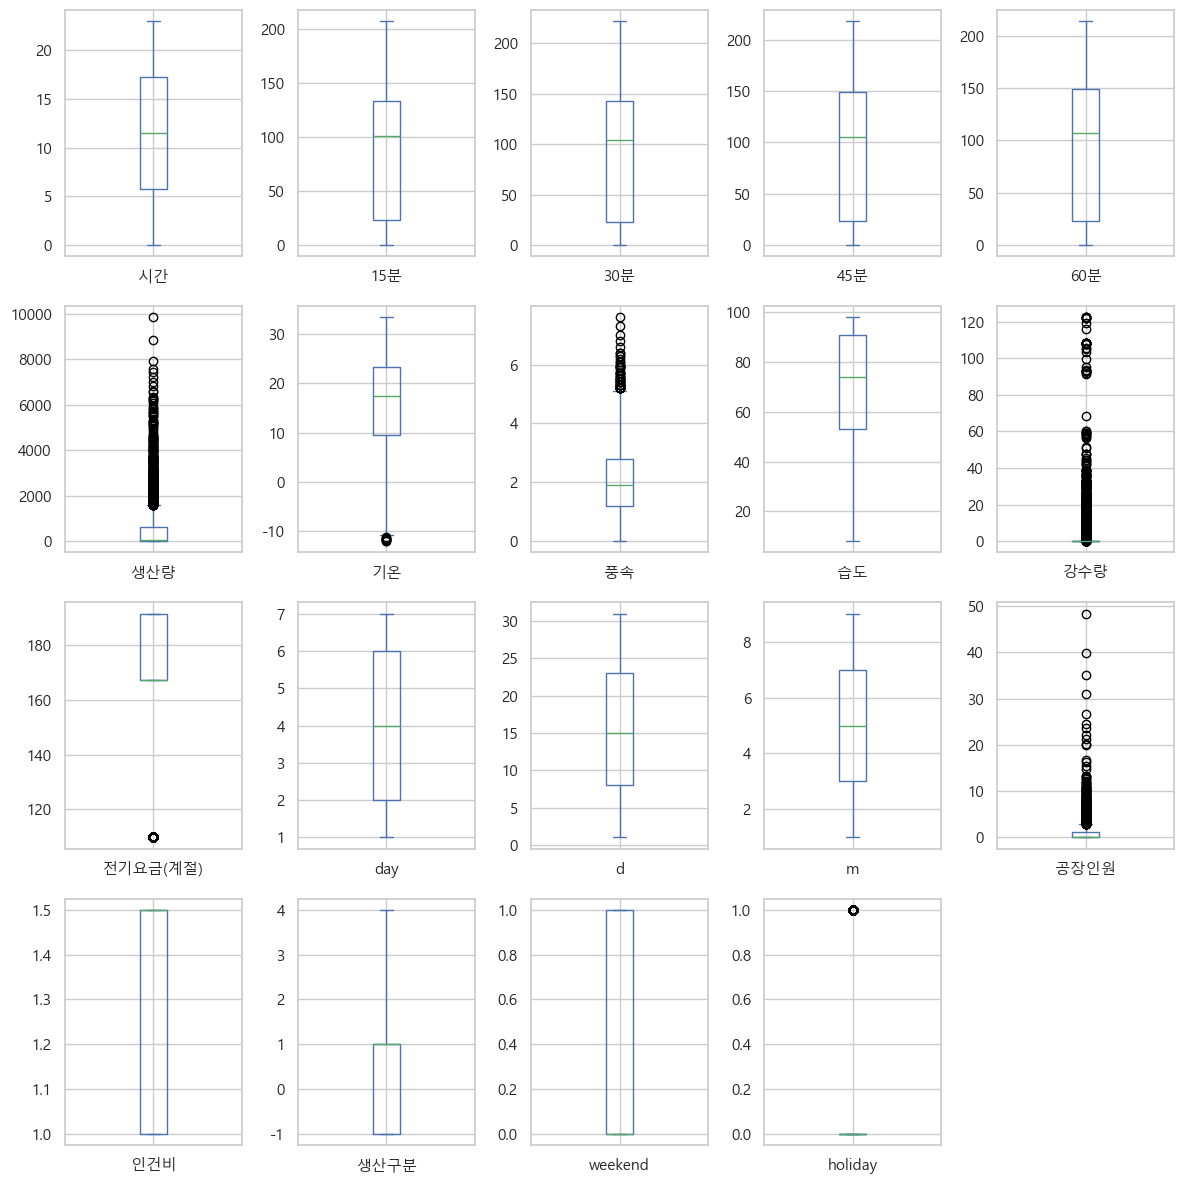

In [150]:
power_df.plot(kind='box', subplots=True, layout=(-1, 5), figsize=(12, 12))
plt.tight_layout()
plt.show()

* 생산량, 강수량, 공장인원은 log 함수 적용

In [36]:
len(power_df)

6168

## 3.1 데이터 로그 적용 및 데이터 분리

In [151]:
# 데이터 컬럼 분류

# log 함수 적용 컬럼
log_features = ['생산량', '강수량', '공장인원', '풍속']

# X
source_features = ['시간', '생산량', '기온', '풍속', '습도', '강수량', 'day', 'd', 'm', '생산구분', 'weekend', 'holiday']
source_features_blind = ['시간', '기온', '풍속', '습도', '강수량', 'day', 'd', 'm', 'weekend', 'holiday']  # '생산량' 이 빠짐 (깜깜이 예측)

# y
target_features = ['15분', '30분', '45분', '60분']

# C : 행후 생산량에 따른 비용 최적화
cost_features = ['생산량', '전기요금(계절)', '공장인원', '인건비']


** 일자별로 테스트 데이터 분리

In [152]:
power_df.index.normalize().unique()  # 일자만 추출

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2021-09-05', '2021-09-06', '2021-09-07', '2021-09-08',
               '2021-09-09', '2021-09-10', '2021-09-11', '2021-09-12',
               '2021-09-13', '2021-09-14'],
              dtype='datetime64[us]', name='datehour', length=257, freq=None)

In [172]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. 데이터 전처리 - 우상향 데이터에 대한 로그함수 적용


#2. 독립변수와 종속변수 구분
X = power_df[source_features]
y = power_df[target_features] 
C = power_df[cost_features]

#2.1 독립변수에 대해 로그함수 적용 : Long Tail 데이터 
for col in log_features:
    if col in X.columns :
        X[col] = np.log1p(power_df[col])

#3 학습데이터와 테스트 데아터로 분리 - 일자별로 분리
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 고유 날짜 추출 (index가 datetime 형식일 때)
unique_dates = power_df.index.normalize().unique() 

# 4. 날짜를 8:2로 분할
train_dates, test_dates = train_test_split(unique_dates, test_size=0.3, random_state=42)

# 5. 날짜 리스트를 기준으로 마스크 생성 및 데이터 분리
train_mask = power_df.index.normalize().isin(train_dates)
test_mask = power_df.index.normalize().isin(test_dates)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

C_train = C.loc[train_mask]
C_test = C.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]


In [154]:
X_test

,시간,생산량,기온,풍속,습도,강수량,day,d,m,생산구분,weekend,holiday
datehour,,,,,,,,,,,,
2021-01-07 00:00:00,0,0.000000,-2.2,0.641854,53,0.0,4,7,1,-1,0,0
2021-01-07 01:00:00,1,3.555348,-2.3,0.832909,55,0.0,4,7,1,4,0,0
2021-01-07 02:00:00,2,0.000000,-1.2,1.435085,55,0.0,4,7,1,-1,0,0
2021-01-07 03:00:00,3,4.043051,-1.0,1.386294,55,0.0,4,7,1,4,0,0
2021-01-07 04:00:00,4,5.631212,-1.4,1.609438,43,0.0,4,7,1,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,19,7.944847,22.3,1.131402,78,0.0,1,13,9,1,0,0
2021-09-13 20:00:00,20,2.708050,22.2,0.832909,78,0.0,1,13,9,1,0,0
2021-09-13 21:00:00,21,4.290459,21.9,1.064711,77,0.0,1,13,9,1,0,0


In [155]:
y_test

,15분,30분,45분,60분
datehour,,,,
2021-01-07 00:00:00,22,22,22,25
2021-01-07 01:00:00,26,22,22,22
2021-01-07 02:00:00,22,21,21,22
2021-01-07 03:00:00,22,22,22,23
2021-01-07 04:00:00,22,26,26,23
...,...,...,...,...
2021-09-13 19:00:00,162,160,148,122
2021-09-13 20:00:00,113,122,122,126
2021-09-13 21:00:00,122,131,122,115


## 3.2 Random-Forest 학습 및 최적화

### 1차 최적화 : 시간이 오래 걸림 : 결과만 확인해도 됨

In [166]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# 2. 1차 GridSearchCV 설정 (범위를 넓게 잡음)
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# 3. 결과 확인
print("--- 1차 최적 파라미터 ---")
print(grid_search.best_params_)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# 4. 최적 모델 추출 및 평가
y_pred = best_model.predict(X_test)

print(f"최종 MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

--- 1차 최적 파라미터 ---
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
최종 MAE: 18.6110
RMSE: 28.8411
R2 Score: 0.7333


### 2차 최적화 : 이전 최적화 파라미터에서 일부만 조정

In [177]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1차 최적화 데이터를 이용하여, 최적화 대상 조정 : 이전 최적화 파라미터 이용
inital_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20, 
    min_samples_split=10,
    max_features='sqrt',
    random_state=42
)

# 특정 파라미터(들)에 대하 세부 조정 최적화
param_grid_update = {
    'n_estimators': [200, 250, 300],       # 최적값 세분화
    'max_depth': [10, 15, 20],         # 깊이를 좀 더 세분화
    'min_samples_split': [5],       # 기존 최적화 값 인용
    'max_features': ['sqrt']          # 기존 최적화 값 인용
}

# 2차 GridSearchCV 진행
grid_search_final = GridSearchCV(inital_model, param_grid_update, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search_final.fit(X_train, y_train)

# 최종 모델 평가
rf_model = grid_search_final.best_estimator_
y_pred = rf_model.predict(X_test)

print("--- 최종 최적 파라미터 ---")
print(grid_search_final.best_params_)
print(f"최고 R2 Score (CV): {grid_search_final.best_score_:.4f}")

print('-'*80)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

--- 최종 최적 파라미터 ---
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 250}
최고 R2 Score (CV): -1241.7074
--------------------------------------------------------------------------------
MAE: 17.7562
RMSE: 28.1043
R2 Score: 0.7467


* 최적화 값 변동 사항 없음

### 세부 종속 변수별 성능값 확인

In [157]:

# 각 변수별 성능 지표 계산
maes = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
rmses = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
r2s = r2_score(y_test, y_pred, multioutput='raw_values')

# 컬럼명과 매칭하여 출력
for col, mae, rmse, r2 in zip(target_features, maes, rmses, r2s):
    print(f"[{col}] MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

[15분] MAE: 18.1446, RMSE: 27.1758, R2: 0.7399
[30분] MAE: 17.9756, RMSE: 28.1675, R2: 0.7467
[45분] MAE: 17.3679, RMSE: 28.3857, R2: 0.7519
[60분] MAE: 17.7810, RMSE: 28.2686, R2: 0.7557


In [44]:
y_pred

array([[ 42.43901371,  42.41421011,  43.60156091,  43.8188749 ],
       [ 53.72630337,  55.09780186,  57.21133518,  58.10038616],
       [ 41.95945145,  42.07588805,  43.47960741,  44.31727346],
       ...,
       [116.80539452, 118.16614958, 120.3364435 , 121.96034588],
       [108.79718688, 114.8730695 , 115.98803549, 115.8106909 ],
       [117.30196092, 119.42775265, 121.92061139, 114.09016501]],
      shape=(1872, 4))

## 3.3 테스트값과 예측값 비교 - 시각화

테스트 값과 예측값 합치기

In [158]:
# 원본 보존을 위해 복사본 생성 (선택 사항)
results_df = y_test.copy()

# y_pred(numpy array)의 각 열을 '{기존열이름}_예측'으로 추가
for i, col in enumerate(target_features):
    results_df[f"{col}_예측"] = y_pred[:, i]

# 확인
print(results_df.head())

                     15분  30분  45분  60분     15분_예측     30분_예측     45분_예측  \
datehour                                                                   
2021-01-07 00:00:00   22   22   22   25  47.564720  47.256651  48.871892   
2021-01-07 01:00:00   26   22   22   22  35.645025  35.800388  37.417704   
2021-01-07 02:00:00   22   21   21   22  51.778572  51.999202  53.622268   
2021-01-07 03:00:00   22   22   22   23  39.631973  39.297683  41.323756   
2021-01-07 04:00:00   22   26   26   23  45.446524  44.683830  47.963485   

                        60분_예측  
datehour                        
2021-01-07 00:00:00  49.873672  
2021-01-07 01:00:00  37.706923  
2021-01-07 02:00:00  54.580260  
2021-01-07 03:00:00  42.267445  
2021-01-07 04:00:00  49.806766  


### 비교의 단순화를 위해 최대값만 비교
* 예를 들어, 30분에서 최대값이면 '30분_예측' 값을 '최대_예측' 값으로 설정

In [159]:
# 1. 실제값 중 최대값과 해당 시점(컬럼명) 찾기
results_df['최대'] = results_df[target_features].max(axis=1)
max_col_names = results_df[target_features].idxmax(axis=1) # 각 행별 최대값의 컬럼명 (예: '30분')

# 2. '최대_예측' 컬럼 생성: 각 행의 최대 시점에 해당하는 예측값 추출
# lookup 방식이나 apply를 활용하여 매칭된 예측 컬럼값을 가져옵니다.
results_df['최대_예측'] = results_df.apply(
    lambda x: x[f"{x.name}_예측"] if isinstance(x.name, str) else x[f"{max_col_names[x.name]}_예측"], 
    axis=1
)

# 더 직관적인 index 기반 방식 (데이터가 클 때 추천)
results_df['최대_예측'] = [results_df.loc[i, f"{col}_예측"] for i, col in zip(results_df.index, max_col_names)]

print(results_df[['최대', '최대_예측']].head())


                     최대      최대_예측
datehour                          
2021-01-07 00:00:00  25  49.873672
2021-01-07 01:00:00  26  35.645025
2021-01-07 02:00:00  22  51.778572
2021-01-07 03:00:00  23  42.267445
2021-01-07 04:00:00  26  44.683830


In [160]:
results_df

,15분,30분,45분,60분,15분_예측,30분_예측,45분_예측,60분_예측,최대,최대_예측
datehour,,,,,,,,,,
2021-01-07 00:00:00,22,22,22,25,47.564720,47.256651,48.871892,49.873672,25,49.873672
2021-01-07 01:00:00,26,22,22,22,35.645025,35.800388,37.417704,37.706923,26,35.645025
2021-01-07 02:00:00,22,21,21,22,51.778572,51.999202,53.622268,54.580260,22,51.778572
2021-01-07 03:00:00,22,22,22,23,39.631973,39.297683,41.323756,42.267445,23,42.267445
2021-01-07 04:00:00,22,26,26,23,45.446524,44.683830,47.963485,49.806766,26,44.683830
...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,162,160,148,122,153.012932,149.349014,151.056259,139.467456,162,153.012932
2021-09-13 20:00:00,113,122,122,126,115.245354,119.262340,119.369695,119.434497,126,119.434497
2021-09-13 21:00:00,122,131,122,115,114.920571,118.510909,118.788464,118.632537,131,118.510909


### 시각화 - 당일 최대값과 대응되는 예측값 비교

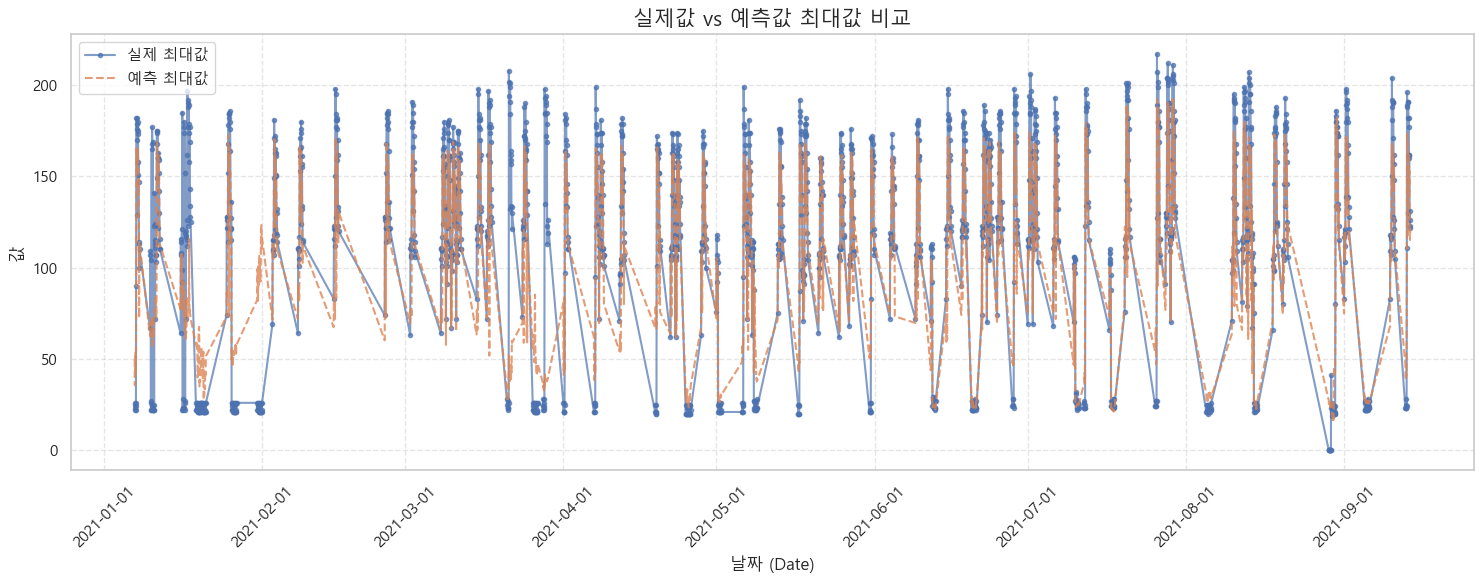

In [161]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 6))

# 1. 인덱스를 날짜순으로 정렬
results_df = results_df.sort_index()

# 데이터 시각화
plt.plot(results_df.index, results_df['최대'], label='실제 최대값', marker='o', markersize=3, alpha=0.7)
plt.plot(results_df.index, results_df['최대_예측'], label='예측 최대값', linestyle='--', alpha=0.8)

# X축 날짜 간격 설정 (데이터가 많을 경우 대비)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # 자동으로 적절한 간격 선택
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 날짜 형식 지정

plt.title('실제값 vs 예측값 최대값 비교', fontsize=15)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('값', fontsize=12)
plt.xticks(rotation=45) # 날짜 겹침 방지
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


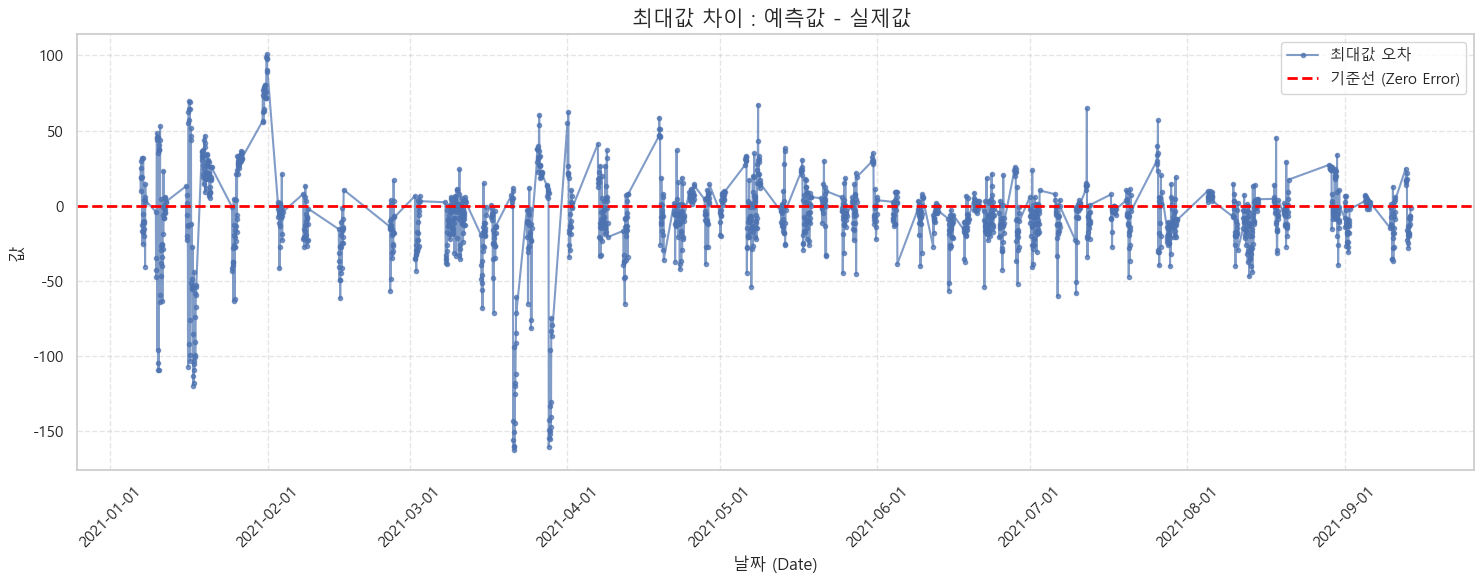

In [162]:
# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 6))

# 1. 인덱스를 날짜순으로 정렬
results_df = results_df.sort_index()

# 데이터 시각화
plt.plot(results_df.index, results_df['최대_예측'] - results_df['최대'], label='최대값 오차', marker='o', markersize=3, alpha=0.7)
# plt.plot(results_df.index, results_df['최대_예측'], label='예측 최대값', linestyle='--', alpha=0.8)

# --- y=0 기준 라인 추가 ---
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='기준선 (Zero Error)')
# -----------------------

# X축 날짜 간격 설정 (데이터가 많을 경우 대비)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # 자동으로 적절한 간격 선택
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 날짜 형식 지정

plt.title('최대값 차이 : 예측값 - 실제값 ', fontsize=15)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('값', fontsize=12)
plt.xticks(rotation=45) # 날짜 겹침 방지
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### 예측시 각 변수별 중요도

C:\Users\Admin\AppData\Local\Temp\ipykernel_3364\1103570837.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


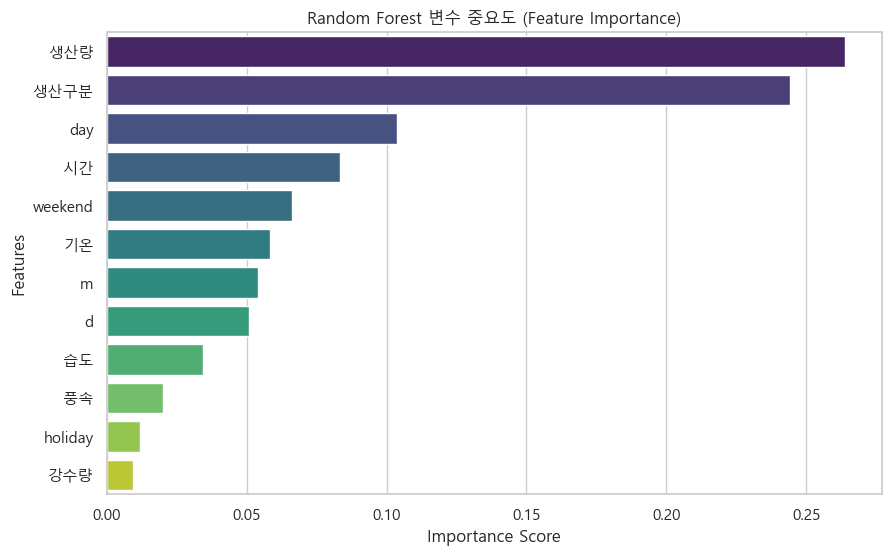

    Feature  Importance
1       생산량    0.263766
9      생산구분    0.244229
6       day    0.103646
0        시간    0.083474
10  weekend    0.066371
2        기온    0.058214
8         m    0.053996
7         d    0.050927
4        습도    0.034256
3        풍속    0.019995
11  holiday    0.011924
5       강수량    0.009203


In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 데이터프레임 변환
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. 중요도 순으로 정렬
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest 변수 중요도 (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 4. 수치로 확인
print(feature_imp_df)

## 3.4 생산량 변수를 제외하고 전력량 예측 (깜깜이 예측 - 시계열 분석과 비교)

In [179]:
XB = power_df[source_features_blind]


XB_train = XB.loc[train_mask]
XB_test = XB.loc[test_mask]

### 최적화 및 확인

In [180]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. 1차 GridSearchCV 설정 (범위를 넓게 잡음)
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [8, 10],
    'max_features': [None, 'sqrt']
}

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(XB_train, y_train)

# 3. 결과 확인
print("--- 1차 최적 파라미터 ---")
print(grid_search.best_params_)
print(f"최고 R2 Score (CV): {grid_search.best_score_:.4f}")
best_params = grid_search.best_params_
blind_model = grid_search.best_estimator_

# 4. 최적 모델 추출 및 평가
y_pred = blind_model.predict(XB_test)

print('-'*80)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

--- 1차 최적 파라미터 ---
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
최고 R2 Score (CV): -1770.5661
--------------------------------------------------------------------------------
MAE: 23.0188
RMSE: 33.9393
R2 Score: 0.6307


### 성능 비교

1. 생산량 포함 예측
- {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
- MAE: 18.2557
- RMSE: 28.4949
- R2 Score: 0.7397

1-2. 생산량 + 생산구분 포함 예측
- {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 150}
- MAE: 17.8173
- RMSE: 28.0036
- R2 Score: 0.7485 
=> 다소 상승

- {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 250}
- MAE: 17.7562
- RMSE: 28.1043
- R2 Score: 0.7467


21. 생산량 없이 예측 - 깜깜이
- {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
- MAE: 23.0143
- RMSE: 33.9270
- R2 Score: 0.6309


In [181]:
# 원본 보존을 위해 복사본 생성 (선택 사항)
blind_df = y_test.copy()

# y_pred(numpy array)의 각 열을 '{기존열이름}_예측'으로 추가
for i, col in enumerate(target_features):
    blind_df[f"{col}_예측"] = y_pred[:, i]


# 1. 실제값 중 최대값과 해당 시점(컬럼명) 찾기
blind_df['최대'] = blind_df[target_features].max(axis=1)
max_col_names = blind_df[target_features].idxmax(axis=1) # 각 행별 최대값의 컬럼명 (예: '30분')

# 2. '최대_예측' 컬럼 생성: 각 행의 최대 시점에 해당하는 예측값 추출
# lookup 방식이나 apply를 활용하여 매칭된 예측 컬럼값을 가져옵니다.
blind_df['최대_예측'] = blind_df.apply(
    lambda x: x[f"{x.name}_예측"] if isinstance(x.name, str) else x[f"{max_col_names[x.name]}_예측"], 
    axis=1
)

# 더 직관적인 index 기반 방식 (데이터가 클 때 추천)
blind_df['최대_예측'] = [blind_df.loc[i, f"{col}_예측"] for i, col in zip(blind_df.index, max_col_names)]

print(blind_df[['최대', '최대_예측']].head())

                     최대      최대_예측
datehour                          
2021-01-07 00:00:00  25  43.738428
2021-01-07 01:00:00  26  40.404575
2021-01-07 02:00:00  22  43.597626
2021-01-07 03:00:00  23  45.026362
2021-01-07 04:00:00  26  47.045943


In [182]:
blind_df

,15분,30분,45분,60분,15분_예측,30분_예측,45분_예측,60분_예측,최대,최대_예측
datehour,,,,,,,,,,
2021-01-07 00:00:00,22,22,22,25,41.905808,41.962985,43.437932,43.738428,25,43.738428
2021-01-07 01:00:00,26,22,22,22,40.404575,40.978179,42.128375,42.845123,26,40.404575
2021-01-07 02:00:00,22,21,21,22,43.597626,44.104591,45.396677,46.229325,22,43.597626
2021-01-07 03:00:00,22,22,22,23,42.124778,42.608002,43.894161,45.026362,23,45.026362
2021-01-07 04:00:00,22,26,26,23,47.074152,47.045943,48.542385,49.745627,26,47.045943
...,...,...,...,...,...,...,...,...,...,...
2021-09-13 19:00:00,162,160,148,122,143.635060,141.851198,146.089047,138.565777,162,143.635060
2021-09-13 20:00:00,113,122,122,126,120.169043,124.335608,124.455355,122.316399,126,122.316399
2021-09-13 21:00:00,122,131,122,115,121.469109,124.998594,124.818466,121.936542,131,124.998594


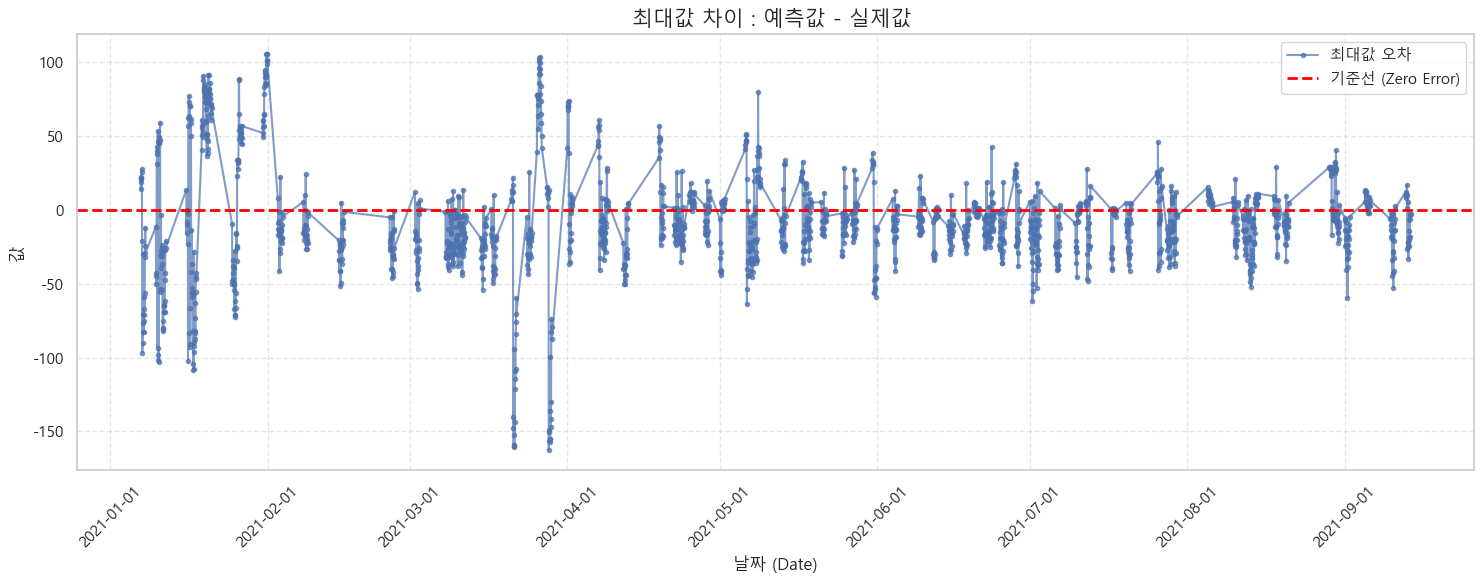

In [183]:
# 한글 깨짐 방지 (필요 시 설정)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 6))

# 1. 인덱스를 날짜순으로 정렬
results_df = results_df.sort_index()

# 데이터 시각화
plt.plot(results_df.index, blind_df['최대_예측'] - blind_df['최대'], label='최대값 오차', marker='o', markersize=3, alpha=0.7)
# plt.plot(results_df.index, results_df['최대_예측'], label='예측 최대값', linestyle='--', alpha=0.8)

# --- y=0 기준 라인 추가 ---
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='기준선 (Zero Error)')
# -----------------------

# X축 날짜 간격 설정 (데이터가 많을 경우 대비)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # 자동으로 적절한 간격 선택
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 날짜 형식 지정

plt.title('최대값 차이 : 예측값 - 실제값 ', fontsize=15)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('값', fontsize=12)
plt.xticks(rotation=45) # 날짜 겹침 방지
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3364\3774941083.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


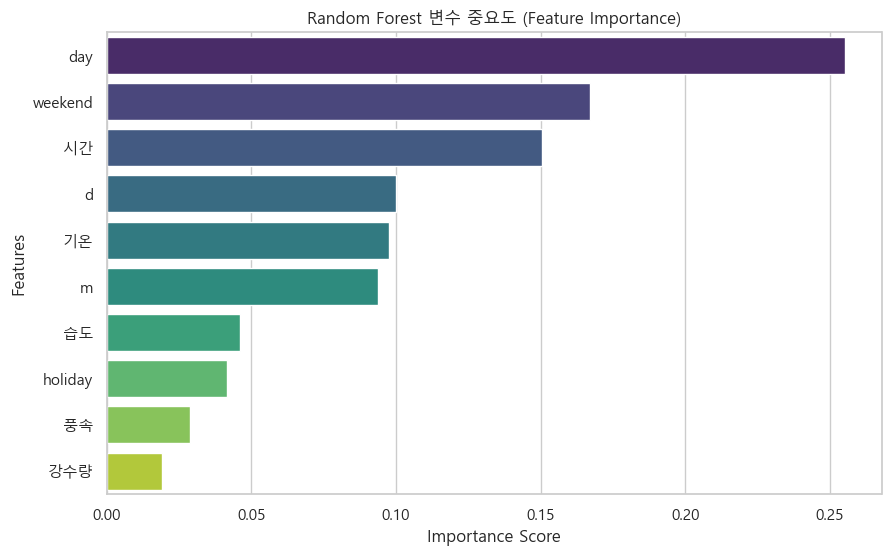

   Feature  Importance
5      day    0.255003
8  weekend    0.166980
0       시간    0.150466
6        d    0.100052
1       기온    0.097679
7        m    0.093717
3       습도    0.046110
9  holiday    0.041668
2       풍속    0.029009
4      강수량    0.019315


In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 데이터프레임 변환
importances = blind_model.feature_importances_
feature_names = XB_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. 중요도 순으로 정렬
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest 변수 중요도 (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 4. 수치로 확인
print(feature_imp_df)

## 3.5 XGBoost 학습 및 최적화

In [185]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — XGBoost (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

# 1. 파라미터 후보 등록
param_dist_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

# 2. RandomizedSearchCV : 전체 조합 중에서 지정한 횟수만큼만 무작위로 골라 테스트
random_search = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, verbosity=0, n_jobs=1), 
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)

random_search.fit(X_train, y_train)

# 3. 최적의 파라미터 및 모델 추출
print("\n" + "-"*100)
print(f"최적 하이퍼파라미터: {random_search.best_params_}")
print(f"최고 R2 Score (CV): {random_search.best_score_:.4f}")
print("-"*100)

best_model = random_search.best_estimator_

# 4. 예측 수행
y_pred = best_model.predict(X_test)

# 5. 성능 지표 계산 및 출력
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n[ 테스트 데이터셋 평가 결과 ]")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print("="*55)

  하이퍼파라미터 튜닝 — XGBoost (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
최고 R2 Score (CV): 0.6409
----------------------------------------------------------------------------------------------------

[ 테스트 데이터셋 평가 결과 ]
MAE  : 14.7895
RMSE : 23.6083
R2   : 0.8215


In [36]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — XGBoost (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

# 1. 파라미터 후보 등록
param_dist_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

# 2. RandomizedSearchCV : 전체 조합 중에서 지정한 횟수만큼만 무작위로 골라 테스트
random_search = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, verbosity=0, n_jobs=1), 
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)

# random_search.fit(X_train, y_train)
random_search.fit(XB_train, y_train)

# 3. 최적의 파라미터 및 모델 추출
print("\n" + "-"*100)
print(f"최적 하이퍼파라미터: {random_search.best_params_}")
print(f"최고 R2 Score (CV): {random_search.best_score_:.4f}")
print("-"*100)

blind_xgb_model = random_search.best_estimator_

# 4. 예측 수행
# y_pred = blind_xgb_model.predict(X_test)
y_pred = blind_xgb_model.predict(XB_test)

# 5. 성능 지표 계산 및 출력
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n[ 테스트 데이터셋 평가 결과 ]")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print("="*55)

  하이퍼파라미터 튜닝 — XGBoost (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

----------------------------------------------------------------------------------------------------
최적 하이퍼파라미터: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
최고 R2 Score (CV): 0.4418
----------------------------------------------------------------------------------------------------

[ 테스트 데이터셋 평가 결과 ]
MAE  : 18.9956
RMSE : 28.5510
R2   : 0.7385


### XGB 성능 비교

1. 생산량 포함 예측
- {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
- MAE  : 15.7939
- RMSE : 24.0246
- R2   : 0.8148

2. 생산량 + 생산구분
- {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
- MAE  : 14.7895
- RMSE : 23.6083
- R2   : 0.8215

2. 생산량 없이 예측 - 깜깜이
- {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
- MAE: 18.9956
- RMSE: 28.5510
- R2 Score: 0.7385


### Random Forest 성능 비교
1. 생산량 포함 예측
- {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
- MAE: 18.2557
- RMSE: 28.4949
- R2 Score: 0.7397

2. 생산량 없이 예측 - 깜깜이
- {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
- MAE: 23.0143
- RMSE: 33.9270
- R2 Score: 0.6309

==> XGB 가 성능이 높게 나옴

## 3.7 비용 최적화

### 비용 산정
- 전체 비용 = 전력비용 + 인력투입비용
- 전력 비용 = 피크전력 * 전기요금(계절별)
- 인력투입비용 = 공장인원 * 인건비 배율 (주간 1, 야간/휴일 1.5) 

In [186]:
# 비용관련 변수 = 이미 정의됨
# C : 행후 생산량에 따른 비용 최적화
# cost_features = ['생산량', '전기요금(계절)', '공장인원', '인건비']

# C_train = C.loc[train_mask]
# C_test = C.loc[test_mask]

# 종속변수 정의 cy

def build_objective_function_parameters(prediction, y_test, x_test, c_test, index=0):
    
    elec_power_mean = prediction.iloc[index].mean()
    elec_unit_price = c_test['전기요금(계절)'].iloc[index]
    elec_price = elec_power_mean * elec_unit_price / 1000 # 단위 천원
    
    human_cost = c_test['공장인원'].iloc[index] * 50 # 시간 단가 : 50 천원
    
    adjustment = y_test.iloc[index].mean() * 1.1 - x_test['weekend'].iloc[index] * 1.1
    
    total_elec_price = elec_price + adjustment
    total_human_cost = human_cost - adjustment
    
    return total_elec_price, total_human_cost



In [ ]:
from ortools.linear_solver import pywraplp

In [90]:
def objective_function(solver,c_test,cx,cy,x,y,index=0):
    objective = solver.Objective()
    if(c_test[index][0]==1) :
        objective.SetCoefficient(x, cx*2)
        objective.SetCoefficient(y, -cy)
    else:
        objective.SetCoefficient(x, cx//2)
        objective.SetCoefficient(y, -(cy)//2)
    
    objective.SetMinimization()
    return objective

In [48]:
label_cat_names = ['15분','30분','45분','60분']
or_cat_rm_list = ["인건비","전기요금(계절)","공장인원","생산량"]
x_train = []
cost_list = []
for index in range(0,len(power_df)):
    for col in label_cat_names:
        temp = list(power_df.drop(or_cat_rm_list,axis=1).drop(label_cat_names,axis=1).iloc[0])
        temp.append(power_df[col].iloc[index])
        cost_list.append(power_df[or_cat_rm_list].iloc[index])
        x_train.append(temp)
y_labels = []
for index in range(0,len(power_df)):
    for col in label_cat_names:
        y_labels.append(power_df[col].iloc[index])
        y_labels.pop(0)
        x_train.pop(len(x_train)-1)
        cost_list.pop(len(x_train)-1)
        
X = np.asarray(x_train)
C = np.asarray(cost_list)
y = np.asarray(y_labels)

In [72]:
import pandas as pd
import numpy as np

# 1. 컬럼명 정의
# 공통 피처 컬럼들 (제외 대상들을 뺀 나머지)
common_cols = power_df.drop(columns=or_cat_rm_list + label_cat_names).columns.tolist()
# 최종 X 데이터의 컬럼 구성: 공통 피처 + '현재_시점_값'
x_cols = common_cols + ['현재_시점_값']

x_train_list = []
cost_list_data = []
y_labels_list = []

# 2. 데이터 추출 루프
for index in range(len(power_df)):
    for col in label_cat_names:
        # X 데이터: 공통 피처 값들 + 현재 순회 중인 시간대(15분, 30분 등)의 값
        row_features = power_df[common_cols].iloc[index].tolist()
        row_features.append(power_df[col].iloc[index])
        
        x_train_list.append(row_features)
        cost_list_data.append(power_df[or_cat_rm_list].iloc[index].values)
        y_labels_list.append(power_df[col].iloc[index])

# 3. DataFrame 및 Series로 변환
X_df = pd.DataFrame(x_train_list, columns=x_cols)
C_df = pd.DataFrame(cost_list_data, columns=or_cat_rm_list)
y_ser = pd.Series(y_labels_list, name="target_value")

# 결과 확인
print("--- X (학습 피처) 상단 5행 ---")
print(X_df.head())
print("\n--- C (비용 관련 정보) 컬럼 정보 ---")
print(C_df.columns.tolist())


--- X (학습 피처) 상단 5행 ---
    시간   기온        풍속    습도  강수량  day    d    m  weekend  holiday  현재_시점_값
0  0.0 -3.2  0.587346  71.0  0.0  5.0  1.0  1.0      0.0      1.0       62
1  0.0 -3.2  0.587346  71.0  0.0  5.0  1.0  1.0      0.0      1.0       61
2  0.0 -3.2  0.587346  71.0  0.0  5.0  1.0  1.0      0.0      1.0       61
3  0.0 -3.2  0.587346  71.0  0.0  5.0  1.0  1.0      0.0      1.0       61
4  1.0 -4.5  0.501012  77.0  0.0  5.0  1.0  1.0      0.0      1.0       96

--- C (비용 관련 정보) 컬럼 정보 ---
['인건비', '전기요금(계절)', '공장인원', '생산량']


In [56]:
X_df

,시간,기온,풍속,습도,강수량,day,d,m,weekend,holiday,현재_시점_값
0,0.0,-3.2,0.587346,71.0,0.000000,5.0,1.0,1.0,0.0,1.0,62
1,0.0,-3.2,0.587346,71.0,0.000000,5.0,1.0,1.0,0.0,1.0,61
2,0.0,-3.2,0.587346,71.0,0.000000,5.0,1.0,1.0,0.0,1.0,61
3,0.0,-3.2,0.587346,71.0,0.000000,5.0,1.0,1.0,0.0,1.0,61
4,1.0,-4.5,0.501012,77.0,0.000000,5.0,1.0,1.0,0.0,1.0,96
...,...,...,...,...,...,...,...,...,...,...,...
24667,22.0,22.0,0.594518,79.0,0.791413,2.0,14.0,9.0,0.0,0.0,114
24668,23.0,22.0,0.594518,79.0,0.791413,2.0,14.0,9.0,0.0,0.0,117
24669,23.0,22.0,0.594518,79.0,0.791413,2.0,14.0,9.0,0.0,0.0,119
24670,23.0,22.0,0.594518,79.0,0.791413,2.0,14.0,9.0,0.0,0.0,112


In [74]:
C_df

,인건비,전기요금(계절),공장인원,생산량
0,1.5,109.8,0.000000,0.000000
1,1.5,109.8,0.000000,0.000000
2,1.5,109.8,0.000000,0.000000
3,1.5,109.8,0.000000,0.000000
4,1.5,109.8,0.000000,0.000000
...,...,...,...,...
24667,1.5,167.2,0.122256,0.974394
24668,1.5,167.2,0.407454,1.080726
24669,1.5,167.2,0.407454,1.080726
24670,1.5,167.2,0.407454,1.080726


In [57]:
y_ser

0         62
1         61
2         61
3         61
4         96
        ... 
24667    114
24668    117
24669    119
24670    112
24671     91
Name: target_value, Length: 24672, dtype: int64

In [93]:
rates_df = pd.read_csv('./data/electricity_tariff.csv')

rates_df = rates_df.set_index('시간', drop=True)

rates_df.head(24)

,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
시간,,,,,,,,,,,,
0,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
1,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
2,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
3,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
4,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
5,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
6,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
7,103.1,103.1,95.7,95.7,95.7,95.7,95.7,95.7,95.7,95.7,103.1,103.1
8,120.0,120.0,100.5,100.5,100.5,121.5,121.5,121.5,100.5,100.5,120.0,120.0


## 4. 기상청 실시간 예보 데이터 조회 (API)

In [2]:
import requests
import datetime
import urllib3
import os
from urllib.parse import unquote
from dotenv import load_dotenv

# HTTPS 경고 메시지 무시 설정
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def get_service_key():
    load_dotenv()
    raw_key = os.getenv("SERVICE_KEY")
    return unquote(raw_key)

# 하늘상태(SKY) 및 강수형태(PTY) 코드 변환 함수
def get_sky_status(sky_code, pty_code):
    # 강수 형태(PTY) 우선 확인
    pty_dict = {'1': '비', '2': '비/눈', '3': '눈', '4': '소나기'}
    if pty_code in pty_dict and pty_code != '0':
        return pty_dict[pty_code]
    
    # 강수 없을 시 하늘 상태(SKY) 확인
    sky_dict = {'1': '맑음', '3': '구름많음', '4': '흐림'}
    return sky_dict.get(sky_code, '-')

def get_weather_final():
    serviceKey = get_service_key() 
    url = "https://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"
    
    now = datetime.datetime.now()
    base_times = [2, 5, 8, 11, 14, 17, 20, 23]
    current_hour = now.hour
    
    past_times = [t for t in base_times if t <= current_hour]
    
    if not past_times:
        base_date = (now - datetime.timedelta(days=1)).strftime('%Y%m%d')
        base_time = "2300"
    else:
        base_date = now.strftime('%Y%m%d')
        base_time = f"{max(past_times):02d}00"

    params = {
        'serviceKey': serviceKey,
        'pageNo': '1',
        'numOfRows': '1000',
        'dataType': 'JSON',
        'base_date': base_date,
        'base_time': base_time,
        'nx': '99',
        'ny': '82'
    }

    try:
        response = requests.get(url, params=params, verify=False)
        res_json = response.json()

        if res_json['response']['header']['resultCode'] == '00':
            items = res_json['response']['body']['items']['item']
            weather_dict = {}

            for item in items:
                time_key = f"{item['fcstDate']} {item['fcstTime'][:2]}:00"
                category = item['category']
                value = item['fcstValue']

                if time_key not in weather_dict:
                    weather_dict[time_key] = {}

                # SKY(하늘상태), PTY(강수형태) 추가 추출
                if category in ['TMP', 'REH', 'PCP', 'WSD', 'SKY', 'PTY']:
                    weather_dict[time_key][category] = value

            print(f"[{params['base_date']} {params['base_time']} 발표] 울주군 삼동면 날씨 예보")
            print("-" * 80)
            print(f"{'예보 시각':<14} | {'상태':<6} | {'기온':>2} | {'습도':>2} | {'풍속':>4} | {'강수량':<8}")
            print("-" * 80)

            for time_str, data in sorted(weather_dict.items()):
                # 상태 메시지 생성
                status = get_sky_status(data.get('SKY'), data.get('PTY'))
                tmp = data.get('TMP', '-')
                reh = data.get('REH', '-')
                wsd = data.get('WSD', '-')
                pcp = data.get('PCP', '강수없음')
                
                print(f"{time_str:<18} | {status:<8} | {tmp:>3}℃ | {reh:>3}% | {wsd:>3}m/s | {pcp}")
        else:
            print(f"오류: {res_json['response']['header']['resultMsg']}")
            
    except Exception as e:
        print(f"데이터 처리 중 오류 발생: {e}")


In [3]:
if __name__ == "__main__":
    get_weather_final()

[20260319 1100 발표] 울주군 삼동면 날씨 예보
--------------------------------------------------------------------------------
예보 시각          | 상태     | 기온 | 습도 |   풍속 | 강수량     
--------------------------------------------------------------------------------
20260319 12:00     | 맑음       |  11℃ |  55% | 1.8m/s | 강수없음
20260319 13:00     | 맑음       |  12℃ |  50% | 1.1m/s | 강수없음
20260319 14:00     | 맑음       |  13℃ |  50% | 0.4m/s | 강수없음
20260319 15:00     | 맑음       |  13℃ |  50% | 0.1m/s | 강수없음
20260319 16:00     | 맑음       |  13℃ |  60% | 0.8m/s | 강수없음
20260319 17:00     | 구름많음     |  11℃ |  65% | 1.7m/s | 강수없음
20260319 18:00     | 구름많음     |  10℃ |  70% | 1.3m/s | 강수없음
20260319 19:00     | 구름많음     |   7℃ |  75% | 0.1m/s | 강수없음
20260319 20:00     | 흐림       |   6℃ |  80% | 0.9m/s | 강수없음
20260319 21:00     | 구름많음     |   6℃ |  85% | 0.9m/s | 강수없음
20260319 22:00     | 구름많음     |   4℃ |  85% | 1.3m/s | 강수없음
20260319 23:00     | 구름많음     |   4℃ |  90% | 2.4m/s | 강수없음
20260320 00:00     | 맑음       |  

In [15]:
import requests
import datetime
import urllib3
import os
import pandas as pd
from urllib.parse import unquote
from dotenv import load_dotenv

# HTTPS 경고 메시지 무시 설정
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def get_service_key():
    load_dotenv()
    raw_key = os.getenv("SERVICE_KEY")
    return unquote(raw_key)

def get_sky_status(sky_code, pty_code):
    """하늘상태와 강수형태 코드를 조합해 한글 상태 반환"""
    pty_dict = {'1': '비', '2': '비/눈', '3': '눈', '4': '소나기'}
    if pty_code in pty_dict and pty_code != '0':
        return pty_dict[pty_code]
    
    sky_dict = {'1': '맑음', '3': '구름많음', '4': '흐림'}
    return sky_dict.get(sky_code, '-')

def get_weather_final(pos_nx, pos_ny):
    serviceKey = get_service_key() 
    url = "https://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst"
    
    # 발표 시각 설정
    now = datetime.datetime.now()
    base_times = [2, 5, 8, 11, 14, 17, 20, 23]
    current_hour = now.hour
    past_times = [t for t in base_times if t <= current_hour]
    
    if not past_times:
        base_date = (now - datetime.timedelta(days=1)).strftime('%Y%m%d')
        base_time = "2300"
    else:
        base_date = now.strftime('%Y%m%d')
        base_time = f"{max(past_times):02d}00"

    # 울산 울주군 삼동면 암리 (중산기업) 기준 nx=99, ny=82
    params = {
        'serviceKey': serviceKey,
        'pageNo': '1',
        'numOfRows': '1000',
        'dataType': 'JSON',
        'base_date': base_date,
        'base_time': base_time,
        'nx': pos_nx, # '99',
        'ny': pos_ny  # '82'
    }

    try:
        response = requests.get(url, params=params, verify=False)
        res_json = response.json()

        if res_json['response']['header']['resultCode'] == '00':
            items = res_json['response']['body']['items']['item']
            weather_dict = {}

            for item in items:
                time_key = f"{item['fcstDate']} {item['fcstTime'][:2]}:00"
                category = item['category']
                value = item['fcstValue']

                if time_key not in weather_dict:
                    weather_dict[time_key] = {}
                if category in ['TMP', 'REH', 'PCP', 'WSD', 'SKY', 'PTY']:
                    weather_dict[time_key][category] = value

            data_list = []
            for time_str, d in sorted(weather_dict.items()):
                # 강수량(PCP) 숫자 변환 로직
                pcp_raw = d.get('PCP', '강수없음')
                if pcp_raw == '강수없음':
                    pcp_val = 0.0
                else:
                    try:
                        # "1.0mm" 등에서 숫자만 추출
                        pcp_val = float(''.join(filter(lambda x: x.isdigit() or x == '.', pcp_raw)))
                    except:
                        pcp_val = 0.0

                data_list.append({
                    '예보시각': time_str,
                    '상태': get_sky_status(d.get('SKY'), d.get('PTY')),
                    'SKY코드': d.get('SKY'),
                    'PTY코드': d.get('PTY'),
                    '기온(℃)': float(d.get('TMP', 0)),
                    '습도(%)': int(d.get('REH', 0)),
                    '풍속(m/s)': float(d.get('WSD', 0)),
                    '강수량(mm)': pcp_val
                })
            
            df = pd.DataFrame(data_list)

            print(f"[{base_date} {base_time} 발표] 울산 삼동면 날씨 예보 (DataFrame)")
            print("-" * 110)
            print(df.to_string(index=False)) 
            print("-" * 110)

            return df
            
        else:
            print(f"API 오류: {res_json['response']['header']['resultMsg']}")
            return None
            
    except Exception as e:
        print(f"데이터 처리 중 오류 발생: {e}")
        return None


In [16]:
if __name__ == "__main__":
    weather_df = get_weather_final('99', '82')
    # 이제 weather_df를 사용하여 추가적인 데이터 분석이나 엑셀 저장이 가능합니다.

weather_df

[20260319 1100 발표] 울산 삼동면 날씨 예보 (DataFrame)
--------------------------------------------------------------------------------------------------------------
          예보시각   상태 SKY코드 PTY코드  기온(℃)  습도(%)  풍속(m/s)  강수량(mm)
20260319 12:00   맑음     1     0   11.0     55      1.8      0.0
20260319 13:00   맑음     1     0   12.0     50      1.1      0.0
20260319 14:00   맑음     1     0   13.0     50      0.4      0.0
20260319 15:00   맑음     1     0   13.0     50      0.1      0.0
20260319 16:00   맑음     1     0   13.0     60      0.8      0.0
20260319 17:00 구름많음     3     0   11.0     65      1.7      0.0
20260319 18:00 구름많음     3     0   10.0     70      1.3      0.0
20260319 19:00 구름많음     3     0    7.0     75      0.1      0.0
20260319 20:00   흐림     4     0    6.0     80      0.9      0.0
20260319 21:00 구름많음     3     0    6.0     85      0.9      0.0
20260319 22:00 구름많음     3     0    4.0     85      1.3      0.0
20260319 23:00 구름많음     3     0    4.0     90      2.4      0.0
20260320 00:0

,예보시각,상태,SKY코드,PTY코드,기온(℃),습도(%),풍속(m/s),강수량(mm)
0,20260319 12:00,맑음,1,0,11.0,55,1.8,0.0
1,20260319 13:00,맑음,1,0,12.0,50,1.1,0.0
2,20260319 14:00,맑음,1,0,13.0,50,0.4,0.0
3,20260319 15:00,맑음,1,0,13.0,50,0.1,0.0
4,20260319 16:00,맑음,1,0,13.0,60,0.8,0.0
...,...,...,...,...,...,...,...,...
64,20260322 12:00,구름많음,3,0,12.0,30,1.0,0.0
65,20260322 15:00,구름많음,3,0,14.0,30,1.0,0.0
66,20260322 18:00,흐림,4,0,12.0,55,1.0,0.0
67,20260322 21:00,흐림,4,0,9.0,70,1.0,0.0
